# **Forecasting Under Regime Instability**: Structural Break Testing and Feature Correlation Analysis

## **Purpose**
This notebook tests whether COVID-19 induced a structural break in the relationships between labor market signals and future wage growth and inflation.

### Problem Statement
COVID-19 pandemic disrupted economic relationships established over decades. Labor market indicators like the job-openings-to-unemployment ratio, quits rates, and unemployment levels have historically predicted future wage growth and inflation. The pandemic shock created unprecedented labor market changes: job losses were immediate and massive, followed by an unusual combination of rapid rehiring, widespread worker exits from the labor force, and historically tight labor markets despite elevated unemployment. This raises the question about whether these relationships still remain the same. If labor market signals lost predictive power or  fundamentally changed the relationships between inflation and wages, forecasts based on pre-pandemic models will systematically fail.

### Objective
The goal of this notebook is to test if labor market signals remained reliable predictors after COVID-19 or became regime-dependent. This is done using Augmented Dickey-Fuller tests for stationarity, mean tests across regime breaks, Chow tests to detect structural breaks in regression coefficients, sup-F tests to identify the exact breakpoint, CUSUM tests for model stability, and correlation analysis to assess signal persistence. The analysis aims to answer the following questions:
* Did COVID-19 constitute a statistically significant structural break in forecasting equations?
* If a break occurred, did parameters shift, did signals become uninformative, or both?
* Do different labor market signals exhibit different types of breaks?



### Scope and Limitations
The analysis is limited to monthly U.S. data from January 2000 through April 2026. It focuses: on three regimes: 
* pre-pandemic baseline (January 2000–February 2020),
* pandemic shock (March 2020–May 2021),
* and post-pandemic (June 2021 onward).

Wage growth is measured using private sector average hourly earnings forward growth at 3-, 6-, and 12-month horizons.  Inflation uses headline CPI and PCE. 

Labor market tightness is measured using the job-openings-to-unemployment ratio, unemployment rates, and quits rates.

The analysis does not adjust for compositional labor force shifts or employment quality. Forecasting equations use ordinary least squares with 12-month lag HAC adjustments. 

## **Research Context**

The United States experienced unprecedented labor market volatility during 2020–2021. Unemployment rate spiked to 14.7% in April 2020, the highest it has been the post-World War II, then fell to 3.4% by December 2021. Job quits also surged to record highs, voluntary separations increased, and labor force participation stayed below pre-pandemic levels for a long period of time. Inflation rose sharply from 1.4% annual CPI growth in mid-2020 to peaks above 9% by mid-2022, exceeding the Federal Reserve's 2% target. 

These changes confounded traditional forecasting models built on pre-pandemic relationships. This notebook explores if the shock was temporary or if structural changes in matching, bargaining, or worker preferences have permanently changed the predictability of wages and prices from labor market indicators.

## Imports and Configuration

In [1]:
%matplotlib inline

import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from scipy import stats
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.diagnostic import breaks_cusumolsresid
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller

from regime_shift.config import (
    BREAK_PATH,
    CURVE_PATH,
    EDA_PATH,
    FIG_ROOT,
    FIG_SIZE,
    FIG_TALL,
    FIG_WIDE,
    MERGED_PATH,
    PLOT_STYLE,
    POST_LABEL,
    PRE_LABEL,
    REGIME_DATES,
    REGIME_PATH,
    REPORT_ROOT,
    ROLL_PATH,
    SAVE_DPI,
    SHOCK_LABEL,
    SHOW_DEC,
    STAT_ALPHA,
    UNIT_PATH,
)
from regime_shift.preprocessing import missing_data, set_date

warnings.filterwarnings("ignore")

project_root = Path.cwd().resolve()
src_root = project_root / "src"

sys.path.insert(0, str(src_root))

FIG_ROOT.mkdir(parents=True, exist_ok=True)
REPORT_ROOT.mkdir(parents=True, exist_ok=True)

plt.style.use(PLOT_STYLE)
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Load Dataset

In [2]:
df = pd.read_csv(MERGED_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Data Shape: {df.shape}")
print(f"Date Range: {df['date'].min().date()} to {df['date'].max().date()}")

Data Shape: (316, 135)
Date Range: 2000-01-01 to 2026-04-01


## Data Overview

The merged dataset contains 316 monthly observations and 135 variables from January 2000 to April 2026. The 3 regimes are defined: 
* Pre-2020 encompasses January 2000–February 2020 (240 observations),
* Pandemic Shock covers March 2020–May 2021 (27 observations),
* and Post-Pandemic includes June 2021–April 2026 (49 observations). 

The df.head(3) output displays the first 3 rows of the merged dataset. This is mainly to check if the dataframe is organized at a monthly frequency, that the date column is present, and that the merged macroeconomic indicators are aligned by month. The first rows contain many labor, wage, inflation, financial, and survey variables. Some variables are missing in the earliest rows because not all source series begin in January 2000.

In [3]:
df.head(3)

,date,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,ip_manufacturing,capacity_util,housing_starts,building_permits,new_home_sales,consumer_sentiment,durable_orders,capex_orders,ci_loans,bank_credit,m2,treasury_1m,treasury_3m,treasury_2y,treasury_10y,fed_funds,aaa_yield,baa_yield,hy_oas,bbb_oas,breakeven_5y,breakeven_10y,forward_5y5y,michigan_1y,kcfed_lmci_activity,kcfed_lmci_momentum,recession,output_per_hour,unit_labor_costs,atl_.,atl_..1,atl_..2,atl_..3,atl_..4,atl_..5,atl_..6,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4
0,2000-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0000,"5,708.0000",7.0000,84.4000,67.3000,64.6000,12.7000,13.1000,"131,011.0000","110,440.0000","17,284.0000","106,382.0000","6,752.0000",NaN,NaN,NaN,14.1200,NaN,NaN,NaN,169.3000,179.3000,162.8000,198.6000,199.2000,180.9000,255.6000,165.6000,72.9610,74.3060,2.0000,3.2000,64.3960,324.2000,"9,799.9000","11,441.6690","10,000.3000","261,545.0000","154,486.0000",91.5380,92.2097,80.8292,"1,636.0000","1,727.0000",873.0000,112.0000,"201,360.0000","63,975.0000","1,003.1482","4,535.6747","4,667.6000",NaN,5.4990,6.4400,6.6600,5.4500,7.7800,8.3300,4.7843,1.5486,NaN,NaN,NaN,3.0000,1.4223,0.1313,0.0000,71.2220,85.7060,4.9000,4.9000,5.0000,5.1000,4.9000,4.8000,5.1000,4.5000,5.8000,4.6000,5.1000,5.1000,5.6000,4.9000,5.0000,4.8000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,4.0000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000,169.3000
1,2000-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.1000,"5,858.0000",7.1000,84.4000,67.3000,64.6000,10.8000,12.6000,"131,120.0000","110,521.0000","17,284.0000","106,512.0000","6,730.0000",NaN,NaN,NaN,14.1400,NaN,NaN,NaN,170.0000,179.4000,163.6000,199.2000,199.5000,181.3000,256.5000,166.2000,73.1910,74.4150,2.1200,2.3600,64.5880,289.4000,"9,837.9000","11,488.8140","10,045.9000","265,686.0000","156,286.0000",91.8239,92.4168,80.6792,"1,737.0000","1,692.0000",856.0000,111.3000,"183,911.0000","58,497.0000","1,016.2395","4,554.7975","4,680.9000",NaN,5.7270,6.6105,6.5200,5.7300,7.6800,8.2900,4.9024,1.5471,NaN,NaN,NaN,2.9000,1.3047,0.0259,0.0000,71.2220,85.7060,4.8000,4.9000,4.9000,5.3000,4.9000,4.7000,5.0000,4.4000,5.7000,4.6000,5.1000,5.1000,5.6000,4.8000,5.0000,4.7000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,4.1000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000,170.0000

The df.info() output confirms that the raw merged dataset has 316 rows, 135 columns, one datetime column, and 134 floating-point numeric columns.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Columns: 135 entries, date to phl_cpi_CPI19Q4
dtypes: datetime64[us](1), float64(134)
memory usage: 333.4 KB


The df.columns.tolist() output shows the breadth of the dataset. This is also to make sure the correct variables are called later on.

In [5]:
df.columns.tolist()

['date',
 'job_openings_level',
 'hires_rate',
 'hires_level',
 'quits_rate',
 'quits_level',
 'total_separations_rate',
 'total_separations_level',
 'layoffs_discharges_level',
 'layoffs_discharges_rate',
 'unemployment_rate',
 'unemployment_level',
 'u6_rate',
 'prime_age_lfpr',
 'lfpr',
 'epop_ratio',
 'prime_age_urate',
 'avg_weeks_unemployed',
 'payrolls_nonfarm',
 'payrolls_private',
 'payrolls_manufacturing',
 'payrolls_services',
 'payrolls_construction',
 'ahe_private',
 'awe_private',
 'awh_private',
 'awe_manufacturing',
 'ahe_manufacturing',
 'eci_total',
 'eci_wages',
 'cpi_all',
 'cpi_core',
 'cpi_less_shelter',
 'cpi_services_less_rent',
 'cpi_services_less_energy',
 'cpi_shelter',
 'cpi_medical',
 'cpi_food',
 'pce_price',
 'pce_core',
 'pce_trimmed_12m',
 'pce_trimmed_1m',
 'pce_services',
 'saving_rate',
 'real_dpi',
 'real_pi',
 'real_pi_less_transfers',
 'retail_advance',
 'real_retail',
 'ip_total',
 'ip_manufacturing',
 'capacity_util',
 'housing_starts',
 'buildi

The df.describe() output provides summary statistics for every numeric variable. This table is important because it identifies scale, range, and potential outliers. The descriptive statistics also show that some variables have extreme values, especially during crisis periods.

In [6]:
df.describe()

,date,job_openings_level,hires_rate,hires_level,quits_rate,quits_level,total_separations_rate,total_separations_level,layoffs_discharges_level,layoffs_discharges_rate,unemployment_rate,unemployment_level,u6_rate,prime_age_lfpr,lfpr,epop_ratio,prime_age_urate,avg_weeks_unemployed,payrolls_nonfarm,payrolls_private,payrolls_manufacturing,payrolls_services,payrolls_construction,ahe_private,awe_private,awh_private,awe_manufacturing,ahe_manufacturing,eci_total,eci_wages,cpi_all,cpi_core,cpi_less_shelter,cpi_services_less_rent,cpi_services_less_energy,cpi_shelter,cpi_medical,cpi_food,pce_price,pce_core,pce_trimmed_12m,pce_trimmed_1m,pce_services,saving_rate,real_dpi,real_pi,real_pi_less_transfers,retail_advance,real_retail,ip_total,ip_manufacturing,capacity_util,housing_starts,building_permits,new_home_sales,consumer_sentiment,durable_orders,capex_orders,ci_loans,bank_credit,m2,treasury_1m,treasury_3m,treasury_2y,treasury_10y,fed_funds,aaa_yield,baa_yield,hy_oas,bbb_oas,breakeven_5y,breakeven_10y,forward_5y5y,michigan_1y,kcfed_lmci_activity,kcfed_lmci_momentum,recession,output_per_hour,unit_labor_costs,atl_.,atl_..1,atl_..2,atl_..3,atl_..4,atl_..5,atl_..6,atl_..7,atl_..8,atl_..9,atl_..10,atl_..11,atl_..12,atl_..13,atl_..14,atl_..15,phl_ruc_RUC15Q1,phl_ruc_RUC15Q2,phl_ruc_RUC15Q3,phl_ruc_RUC15Q4,phl_ruc_RUC16Q1,phl_ruc_RUC16Q2,phl_ruc_RUC16Q3,phl_ruc_RUC16Q4,phl_ruc_RUC17Q1,phl_ruc_RUC17Q2,phl_ruc_RUC17Q3,phl_ruc_RUC17Q4,phl_ruc_RUC18Q1,phl_ruc_RUC18Q2,phl_ruc_RUC18Q3,phl_ruc_RUC18Q4,phl_ruc_RUC19Q1,phl_ruc_RUC19Q2,phl_ruc_RUC19Q3,phl_ruc_RUC19Q4,phl_cpi_CPI15Q1,phl_cpi_CPI15Q2,phl_cpi_CPI15Q3,phl_cpi_CPI15Q4,phl_cpi_CPI16Q1,phl_cpi_CPI16Q2,phl_cpi_CPI16Q3,phl_cpi_CPI16Q4,phl_cpi_CPI17Q1,phl_cpi_CPI17Q2,phl_cpi_CPI17Q3,phl_cpi_CPI17Q4,phl_cpi_CPI18Q1,phl_cpi_CPI18Q2,phl_cpi_CPI18Q3,phl_cpi_CPI18Q4,phl_cpi_CPI19Q1,phl_cpi_CPI19Q2,phl_cpi_CPI19Q3,phl_cpi_CPI19Q4
count,316,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,303.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,315.0000,315.0000,315.0000,315.0000,315.0000,241.0000,241.0000,241.0000,315.0000,241.0000,298.0000,298.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,313.0000,314.0000,314.0000,314.0000,313.0000,313.0000,313.0000,314.0000,314.0000,314.0000,315.0000,316.0000,314.0000,298.0000,316.0000,316.0000,315.0000,315.0000,315.0000,315.0000,316.0000,316.0000,280.0000,280.0000,280.0000,314.0000,313.0000,313.0000,315.0000,310.0000,310.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,314.0000,181.0000,184.0000,187.0000,190.0000,193.0000,196.0000,199.0000,202.0000,205.0000,208.0000,211.0000,214.0000,217.0000,220.0000,223.0000,226.0000,229.0000,232.0000,235.0000,238.0000,180.0000,183.0000,186.0000,189.0000,192.0000,195.0000,198.0000,201.0000,205.0000,208.0000,211.0000,214.0000,217.0000,220.0000,223.0000,226.0000,229.0000,232.0000,235.0000,238.0000
mean,2013-02-14 14:25:49.367088,"5,480.3432",3.6818,"5,187.7294",2.0089,"2,849.3003",3.6155,"5,098.3036","1,906.8416",1.3607,5.6318,"8,754.2229",10.2076,82.4175,64.1618,60.5449,25.1096,23.8051,"140,596.4889","118,454.6635","13,168.3397","119,791.6794","6,953.0317",26.7825,921.2136,34.3884,20.0164,26.7342,122.2586,122.6614,234.0820,239.2872,219.2729,303.6515,295.5221,282.7935,420.0986,237.8422,95.8725,95.5088,2.2186,2.2239,93.3256,808.9873,"13,646.7946","15,501.7566","12,848.7236","437,928.2803","182,998.0799",97.2673,97.0312,75.6297,"1,308.3610","1,368.6933",696.4153,81.7325,"223,651.5000","63,658.2580","1,737.2570","10,738.3731","11,853.5662",1.6970,1.9654,2.2773,3.3307,2.0233,4.7957,5.7951,5.3324,1.9693,1.9598,2.1051,2.2507,3.1688,-0.0828,0.0153,0.0889,95.1209,97.6562,3.6812,3.6917,3.8188,3.8268,3.8392,3.6506,3.7255,3.4452,4.0892,3.5108,3.8127,3.9516,3.8197,3.6803,3.8083,3.5691,6.3663

The df.isna().sum() output shows missing-value counts for every variable.

In [7]:
print(df.isna().sum())

date                   0
job_openings_level    13
hires_rate            13
hires_level           13
quits_rate            13
                      ..
phl_cpi_CPI18Q4       90
phl_cpi_CPI19Q1       87
phl_cpi_CPI19Q2       84
phl_cpi_CPI19Q3       81
phl_cpi_CPI19Q4       78
Length: 135, dtype: int64


## Missingness and Outliers Check

The missingness summary shows that the largest missing counts are concentrated in Philadelphia Fed forecast variables, especially the rolling quarter-specific forecast columns. The top missing columns have missing rates above 30 percent and some above 40 percent. This is expected because those variables are not continuous monthly macro indicators in the same way as CPI, PCE, unemployment, or JOLTS.

In [8]:
missing_summary = missing_data(df)
missing_summary.head(20)

,col,missing_count,missing_pct,non_null_count,data_type
0,phl_cpi_CPI15Q1,136,43.0400,180,float64
1,phl_ruc_RUC15Q1,135,42.7200,181,float64
2,phl_cpi_CPI15Q2,133,42.0900,183,float64
3,phl_ruc_RUC15Q2,132,41.7700,184,float64
4,phl_cpi_CPI15Q3,130,41.1400,186,float64
5,phl_ruc_RUC15Q3,129,40.8200,187,float64
6,phl_cpi_CPI15Q4,127,40.1900,189,float64
7,phl_ruc_RUC15Q4,126,39.8700,190,float64
8,phl_cpi_CPI16Q1,124,39.2400,192,float64
9,phl_ruc_RUC16Q1,123,38.9200,193,float64


Job openings are available from December 2000 through February 2026, unemployment level is available from January 2000 through March 2026, average hourly earnings are available from March 2006 through March 2026, ECI total is available from January 2001 through October 2025, CPI is available from January 2000 through March 2026, and PCE is available from January 2000 through February 2026. So wage-growth models using average hourly earnings cannot begin in 2000. They effectively begin in 2006, after enough wage data exist to calculate growth rates.

In [9]:
coverage_rows = []

for col in ["job_openings_level", "unemployment_level", "ahe_private", "eci_total", "cpi_all", "pce_price"]:
    if col in df.columns:
        use = df.loc[df[col].notna(), "date"]
        coverage_rows.append(
            {
                "col": col,
                "start_date": use.min(),
                "end_date": use.max(),
                "count": int(use.shape[0]),
            }
        )

coverage = pd.DataFrame(coverage_rows)
coverage

,col,start_date,end_date,count
0,job_openings_level,2000-12-01,2026-02-01,303
1,unemployment_level,2000-01-01,2026-03-01,314
2,ahe_private,2006-03-01,2026-03-01,241
3,eci_total,2001-01-01,2025-10-01,298
4,cpi_all,2000-01-01,2026-03-01,314
5,pce_price,2000-01-01,2026-02-01,314


The duplicate check reports 0 duplicates for the date, job-openings, and unemployment-level combination

In [10]:
duplicates_check = df[["date", "job_openings_level", "unemployment_level"]].duplicated().sum()
print(f"Duplicates: {duplicates_check}")

Duplicates: 0


## Splits and Helper Functions

### Define the Pre-Pandemic, Shock, and Post-Pandemic Regimes

The regime-date cell defines the pre-pandemic period, the pandemic-shock period, and the post-pandemic period. The notebook uses March 2020 as the candidate COVID shock break and June 2021 as the start of the post-pandemic stabilization regime.  The *pre-pandemic period represents the baseline relationship*. The *pandemic-shock period represents the most disrupted months*. The *post-pandemic period represents the reopening and inflation-surge economy after the initial shock*

In [11]:
pre_start = pd.Timestamp(REGIME_DATES["pre_start"])
pre_end = pd.Timestamp(REGIME_DATES["pre_end"])
shock_start = pd.Timestamp(REGIME_DATES["shock_start"])
shock_end = pd.Timestamp(REGIME_DATES["shock_end"])
post_start = pd.Timestamp(REGIME_DATES["post_start"])

candidate_break = pd.Timestamp("2020-03-01")
stabilize_break = pd.Timestamp(REGIME_DATES["post_start"])

The safe_log function takes the natural log only where values are positive. This is important because logs are undefined for zero or negative values. The job-openings-to-unemployment ratio, average hourly earnings, CPI, and PCE price index should be positive, but this function prevents the notebook from producing invalid values if a bad or zero observation appears.

In [12]:
def safe_log(series):
    return np.log(series.where(series > 0))

### Build the Target Variables and Core Tightness Signal

The set_regime function creates a regime label for each month. It also creates two binary indicators: post_regime and shock_regime.

In [13]:
def set_regime(data):
    out = data.copy()
    out["regime"] = PRE_LABEL
    out.loc[out["date"] >= shock_start, "regime"] = SHOCK_LABEL
    out.loc[out["date"] >= post_start, "regime"] = POST_LABEL
    out["post_regime"] = (out["date"] >= post_start).astype(int)
    out["shock_regime"] = ((out["date"] >= shock_start) & (out["date"] <= shock_end)).astype(int)
    return out

The add_growth function creates log growth rates. Log growth is commonly used in macroeconomic analysis because differences in logs approximate percentage growth. This function is useful for constructing monthly, quarterly, semiannual, or annual growth rates in a consistent way.

In [14]:
def add_growth(data, col, name, horizon):
    out = data.copy()
    out[name] = 100 * (safe_log(out[col]) - safe_log(out[col]).shift(horizon))
    return out

The add_forward function creates forward target variables by shifting an outcome backward in the dataframe. Like for example, shift(-12) places the 12-month-ahead value on the current row.

The current month’s labor-market condition is matched with future wage growth or future inflation, so the model asks whether today’s tightness contains information about what happens later.

In [15]:
def add_forward(data, base_col, prefix, horizon_list):
    out = data.copy()
    for horizon in horizon_list:
        out[f"{prefix}_{horizon}"] = out[base_col].shift(-horizon)
    return out

The add_lag function creates lagged variables. Lags are important because macroeconomic variables are persistent. Inflation today is often related to inflation last month or last year, and wage growth today is often related to previous wage growth. Including lagged target variables helps us separate the predictive value of labor tightness from simple persistence in the outcome.

In [16]:
def add_lag(data, col, horizon_list):
    out = data.copy()
    for horizon in horizon_list:
        out[f"{col}_lag_{horizon}"] = out[col].shift(horizon)
    return out

The sample_table function reports the effective sample used by each target-predictor combination.

In [17]:
def sample_table(data, y_col, x_col, extra_cols=None):
    extra_cols = extra_cols or []
    cols = ["date", y_col, x_col] + extra_cols
    use = data[cols].dropna().copy()
    return pd.DataFrame(
        [
            {
                "y_col": y_col,
                "x_col": x_col,
                "start_date": use["date"].min(),
                "end_date": use["date"].max(),
                "obs": len(use),
            }
        ]
    )

The fit_model function basically estimates ordinary least squares regressions with HAC-adjusted standard errors. Regular least squares estimates the average linear relationship between the target variable and the predictors. HAC standard errors are used because time-series residuals often have autocorrelation and heteroskedasticity. Here, autocorrelation means model errors are correlated across time. Heteroskedasticity means the size of model errors changes over time. HAC adjustments don't change the coefficient estimates, but they do make the reported standard errors and p-values more suitable for time-series data.

In [18]:
def fit_model(data, y_col, x_cols, cov_lag=12):
    use = data[["date", y_col] + x_cols].dropna().copy()
    if len(use) == 0:
        return None, None
    x = sm.add_constant(use[x_cols])
    y = use[y_col]
    model = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": cov_lag})
    return use, model

The coef_table function converts a fitted regression model into a table containing coefficients, standard errors, t-statistics, p-values, R-squared, adjusted R-squared, and observation counts.

In [19]:
def coef_table(model, y_col, label):
    rows = []
    for col in model.params.index:
        rows.append(
            {
                "label": label,
                "y_col": y_col,
                "term": col,
                "coef": model.params[col],
                "std_error": model.bse[col],
                "t_stat": model.tvalues[col],
                "p_value": model.pvalues[col],
                "r2": model.rsquared,
                "adj_r2": model.rsquared_adj,
                "obs": int(model.nobs),
            }
        )
    return pd.DataFrame(rows)

The chow_test function tests *whether a regression relationship changes at a specified break date*. It compares one pooled model estimated over the full sample against two separate models estimated before and after the break date. If separate models fit much better than one pooled model, the F-statistic becomes large and the p-value becomes small. A small p-value means the evidence supports a structural break at that date.

The Chow test is used because this project has clear break dates: March 2020 for the pandemic shock and June 2021 for the post-pandemic regime. The test doesn't prove why the break happened, but it checks whether the forecasting equation behaves differently before and after the chosen date.

In [20]:
def chow_test(data, y_col, x_cols, break_date, cov_lag=12):
    use = data[["date", y_col] + x_cols].dropna().copy()
    use = use.sort_values("date").reset_index(drop=True)

    left = use[use["date"] < break_date].copy()
    right = use[use["date"] >= break_date].copy()

    if len(left) <= len(x_cols) + 2 or len(right) <= len(x_cols) + 2:
        return None

    x_all = sm.add_constant(use[x_cols])
    x_left = sm.add_constant(left[x_cols])
    x_right = sm.add_constant(right[x_cols])

    y_all = use[y_col]
    y_left = left[y_col]
    y_right = right[y_col]

    m_all = sm.OLS(y_all, x_all).fit()
    m_left = sm.OLS(y_left, x_left).fit()
    m_right = sm.OLS(y_right, x_right).fit()

    rss_all = np.sum(m_all.resid ** 2)
    rss_left = np.sum(m_left.resid ** 2)
    rss_right = np.sum(m_right.resid ** 2)

    k = x_all.shape[1]
    n_left = len(left)
    n_right = len(right)

    num = (rss_all - (rss_left + rss_right)) / k
    den = (rss_left + rss_right) / (n_left + n_right - 2 * k)

    if den <= 0:
        return None

    f_stat = num / den
    p_value = 1 - stats.f.cdf(f_stat, k, n_left + n_right - 2 * k)

    return {
        "y_col": y_col,
        "break_date": break_date,
        "f_stat": f_stat,
        "p_value": p_value,
        "n_left": n_left,
        "n_right": n_right,
        "k": k,
    }

The sup_f_test function searches over many possible break dates and keeps the date with the largest Chow-style F-statistic. This is useful because the true break may not occur exactly at March 2020 or June 2021. A relationship can begin changing before the pandemic shock, or the strongest break could appear after reopening and inflation sped up. The sup-F logic asks where the data shows the strongest sign of instability instead of just assuming the break date.The only issue is simple sup-F implementation reports p-values from repeated Chow tests. Those p-values are good for screening evidence, but they should be interpreted carefully since searching over many possible break dates changes the statistical distribution of the maximum test statistic.

In [21]:
def sup_f_test(data, y_col, x_cols, trim_pct=0.15):
    use = data[["date", y_col] + x_cols].dropna().copy()
    use = use.sort_values("date").reset_index(drop=True)

    n = len(use)
    trim = int(n * trim_pct)
    stats_list = []

    if n <= 2 * trim + 10:
        return None, None

    for idx in range(trim, n - trim):
        break_date = use.loc[idx, "date"]
        out = chow_test(use, y_col, x_cols, break_date)
        if out is not None:
            stats_list.append(out)

    if len(stats_list) == 0:
        return None, None

    out = pd.DataFrame(stats_list).sort_values("f_stat", ascending=False).reset_index(drop=True)
    return out.iloc[0].to_dict(), out

The rolling_model function estimates the same regression repeatedly over a moving 60-month window. This is to see if the coefficients are stable over time. If the coefficient on labor tightness is stable, the rolling coefficient should stay in the same range. If the coefficient moves sharply, crosses zero, or spikes around crisis periods, that suggests the relationship is unstable.

In [22]:
def rolling_model(data, y_col, x_cols, window=60, cov_lag=12):
    use = data[["date", y_col] + x_cols].dropna().copy()
    use = use.sort_values("date").reset_index(drop=True)

    rows = []

    for end in range(window, len(use) + 1):
        part = use.iloc[end - window:end].copy()
        x = sm.add_constant(part[x_cols])
        y = part[y_col]
        model = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": cov_lag})

        row = {
            "date": part["date"].iloc[-1],
            "r2": model.rsquared,
            "obs": int(model.nobs),
        }

        for col in model.params.index:
            row[f"coef_{col}"] = model.params[col]
            row[f"se_{col}"] = model.bse[col]

        rows.append(row)

    return pd.DataFrame(rows)

The forward_corr function calculates correlations between the log JOLTS ratio and future outcomes at multiple horizons, separately for the full sample, the pre-pandemic regime, the pandemic-shock regime, and the post-pandemic regime. 

In [23]:
def forward_corr(data, x_col, y_base, horizon_list):
    rows = []

    for horizon in horizon_list:
        name = f"{y_base}_forward_{horizon}"
        use = data[[x_col, name]].dropna().copy()

        if len(use) == 0:
            continue

        rows.append(
            {
                "y_col": y_base,
                "horizon": horizon,
                "corr_all": use[x_col].corr(use[name]),
                "corr_pre": data.loc[data["regime"] == PRE_LABEL, [x_col, name]].dropna().corr().iloc[0, 1],
                "corr_shock": data.loc[data["regime"] == SHOCK_LABEL, [x_col, name]].dropna().corr().iloc[0, 1],
                "corr_post": data.loc[data["regime"] == POST_LABEL, [x_col, name]].dropna().corr().iloc[0, 1],
            }
        )

    return pd.DataFrame(rows)

The vif_table function computes variance inflation factors. A variance inflation factor basically measures how strongly one predictor can be explained by the other predictors in the same model. High VIF values mean multicollinearity. Multicollinearity doesn't make predictions bad, but it makes individual coefficients harder to interpret because the model struggles to separate the independent effect of variables that move together.

In [24]:
def vif_table(data, col_list):
    use = data[col_list].dropna().copy()
    x = sm.add_constant(use)

    rows = []
    for idx, col in enumerate(x.columns):
        if col == "const":
            continue
        rows.append(
            {
                "col": col,
                "vif": variance_inflation_factor(x.values, idx),
            }
        )

    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)

## Target Construction and Regime Definition

The job-openings-to-unemployment ratio is calculated as job openings divided by unemployment level, log version of the ratio is then created. The log ratio is very useful because the raw ratio is skewed and because a one-unit movement in the log ratio has a more proportional interpretation than a one-unit movement in the raw ratio.

Logs of average hourly earnings, CPI, and PCE prices are also created in this cell. These series are the foundation for wage growth and inflation growth rates. 

In [25]:
df = set_regime(df)

df["jolts_ratio"] = df["job_openings_level"] / df["unemployment_level"]
df["log_jolts_ratio"] = safe_log(df["jolts_ratio"])

df["log_ahe_private"] = safe_log(df["ahe_private"])
df["log_cpi_all"] = safe_log(df["cpi_all"])
df["log_pce_price"] = safe_log(df["pce_price"])

The growth-rate cell creates 3-month, 6-month, and 12-month annualized wage growth for average hourly earnings, CPI inflation, and PCE inflation. The 3-month and 6-month growth rates are annualized by multiplying by 12 divided by the horizon. 

A 3-month horizon is more sensitive to short-term shocks. A 12-month horizon is better for medium-term trend behavior. 

In [26]:
df["ahe_3m_pct"] = 100 * (12 / 3) * (df["log_ahe_private"] - df["log_ahe_private"].shift(3))
df["ahe_6m_pct"] = 100 * (12 / 6) * (df["log_ahe_private"] - df["log_ahe_private"].shift(6))
df["ahe_12m_pct"] = 100 * (df["log_ahe_private"] - df["log_ahe_private"].shift(12))

df["cpi_3m_pct"] = 100 * (12 / 3) * (df["log_cpi_all"] - df["log_cpi_all"].shift(3))
df["cpi_6m_pct"] = 100 * (12 / 6) * (df["log_cpi_all"] - df["log_cpi_all"].shift(6))
df["cpi_12m_pct"] = 100 * (df["log_cpi_all"] - df["log_cpi_all"].shift(12))

df["pce_3m_pct"] = 100 * (12 / 3) * (df["log_pce_price"] - df["log_pce_price"].shift(3))
df["pce_6m_pct"] = 100 * (12 / 6) * (df["log_pce_price"] - df["log_pce_price"].shift(6))
df["pce_12m_pct"] = 100 * (df["log_pce_price"] - df["log_pce_price"].shift(12))

The forward-target cell makes wage_forward_3, wage_forward_6, wage_forward_12, cpi_forward_3, cpi_forward_6, cpi_forward_12, pce_forward_3, pce_forward_6, and pce_forward_12. These are the future wage and inflation outcomes that the model tries to predict from current labor-market information.

In [27]:
for horizon in [3, 6, 12]:
    df[f"wage_forward_{horizon}"] = df[f"ahe_{horizon}m_pct"].shift(-horizon)
    df[f"cpi_forward_{horizon}"] = df[f"cpi_{horizon}m_pct"].shift(-horizon)
    df[f"pce_forward_{horizon}"] = df[f"pce_{horizon}m_pct"].shift(-horizon)

The lag-construction cell creates lagged versions of the log JOLTS ratio and lagged 12-month wage, CPI, and PCE growth. Lagged outcome variables are later used as persistence controls.

In [28]:
for horizon in [1, 3, 6, 12]:
    df[f"log_jolts_ratio_lag_{horizon}"] = df["log_jolts_ratio"].shift(horizon)
    df[f"ahe_12m_pct_lag_{horizon}"] = df["ahe_12m_pct"].shift(horizon)
    df[f"cpi_12m_pct_lag_{horizon}"] = df["cpi_12m_pct"].shift(horizon)
    df[f"pce_12m_pct_lag_{horizon}"] = df["pce_12m_pct"].shift(horizon)

The ECI month cell flags January, April, July, and October as ECI release months. ECI is mainly a quarterly compensation measure, so it shouldn't be treated the same as a monthly series unless the release timing and interpolation method are handled. This notebook  doesn't use ECI in the monthly forward analysis because of that reason.

In [29]:
df["eci_month"] = df["date"].dt.month.isin([1, 4, 7, 10]).astype(int)

## Samples and Wage Measure Check

This table reports the samples for each target and horizon. The wage models starts in March 2006, because average hourly earnings data isn't available from the beginning of the full sample. The wage-forward 3-month model has 237 observations, the 6-month model has 235 observations, and the 12-month model has 229 observations. The end date moves earlier since the horizon increases because a 12-month-forward target can't be constructed for the last 12 months of data.

The inflation models begin earlier, in February 2001, because CPI, PCE, and JOLTS-based predictors become available earlier than the wage-growth target. The CPI models have 296, 295, and 289 observations at the 3-, 6-, and 12-month horizons. The PCE models have 297, 295, and 289 observations at the same horizons. The post-pandemic subsample remains much smaller than the full sample. The main conclusion from this table is that the wage and inflation models are not estimated over identical samples. 

In [30]:
sample_rows = []

for y_col, x_col, extra_cols in [
    ("wage_forward_3", "log_jolts_ratio", []),
    ("wage_forward_6", "log_jolts_ratio", []),
    ("wage_forward_12", "log_jolts_ratio", []),
    ("cpi_forward_3", "log_jolts_ratio", ["cpi_12m_pct_lag_1"]),
    ("cpi_forward_6", "log_jolts_ratio", ["cpi_12m_pct_lag_1"]),
    ("cpi_forward_12", "log_jolts_ratio", ["cpi_12m_pct_lag_1"]),
    ("pce_forward_3", "log_jolts_ratio", ["pce_12m_pct_lag_1"]),
    ("pce_forward_6", "log_jolts_ratio", ["pce_12m_pct_lag_1"]),
    ("pce_forward_12", "log_jolts_ratio", ["pce_12m_pct_lag_1"]),
]:
    sample_rows.append(sample_table(df, y_col, x_col, extra_cols))

sample_data = pd.concat(sample_rows, axis=0).reset_index(drop=True)
sample_data

,y_col,x_col,start_date,end_date,obs
0,wage_forward_3,log_jolts_ratio,2006-03-01,2025-12-01,237
1,wage_forward_6,log_jolts_ratio,2006-03-01,2025-09-01,235
2,wage_forward_12,log_jolts_ratio,2006-03-01,2025-03-01,229
3,cpi_forward_3,log_jolts_ratio,2001-02-01,2025-12-01,296
4,cpi_forward_6,log_jolts_ratio,2001-02-01,2025-09-01,295
5,cpi_forward_12,log_jolts_ratio,2001-02-01,2025-03-01,289
6,pce_forward_3,log_jolts_ratio,2001-02-01,2025-11-01,297
7,pce_forward_6,log_jolts_ratio,2001-02-01,2025-08-01,295
8,pce_forward_12,log_jolts_ratio,2001-02-01,2025-02-01,289


In [31]:
sample_data.to_csv(REPORT_ROOT / "03_effective_samples.csv", index=False)

## Core Series and Regime Splits

This table displays the most recent rows for the core series: the raw JOLTS ratio, the log JOLTS ratio, 12-month wage growth, 12-month CPI inflation, and 12-month PCE inflation. It shows some of the latest observations are missing. Macroeconomic datasets often have ragged edges, so some variables are available for the latest month while others are not. 

In [32]:
plot_cols = [
    "date",
    "jolts_ratio",
    "log_jolts_ratio",
    "ahe_12m_pct",
    "cpi_12m_pct",
    "pce_12m_pct",
]
df[plot_cols].tail()

,date,jolts_ratio,log_jolts_ratio,ahe_12m_pct,cpi_12m_pct,pce_12m_pct
311,2025-12-01,0.8730,-0.1358,3.6588,2.6187,2.8374
312,2026-01-01,0.9826,-0.0175,3.5899,2.3631,2.7897
313,2026-02-01,0.9090,-0.0954,3.6874,2.4049,2.7632
314,2026-03-01,NaN,NaN,3.4566,3.2331,NaN
315,2026-04-01,NaN,NaN,NaN,NaN,NaN


The core-series plot has four panels. The first panel shows the job-openings-to-unemployment ratio over time. The x-axis is time, and the y-axis is the ratio of job openings to unemployed workers. The black dashed vertical line marks March 2020, and the dark red dashed vertical line marks June 2021. The ratio declines after the early 2000s, falls sharply around the Great Recession, rises steadily during the 2010s, collapses during the COVID shock, then surges above 2 in 2022 before dropping toward roughly 1 by 2025 and early 2026.

The second panel shows the log job-openings-to-unemployment ratio. It is the same story as the raw ratio but compresses extreme movements. The log ratio makes the 2020 collapse and the 2021–2022 surge easier to compare against earlier cycles. 

The third panel shows 12-month wage growth using average hourly earnings. Wage growth rises before the pandemic, spikes sharply in 2020, drops, rises again during the post-pandemic reopening period, and then gradually declines. The 2020 wage spike should be interpreted carefully because average hourly earnings were affected by workforce composition. Lower-wage workers were disproportionately affected by job losses, which  raised average earnings even when individual wages didn't all jump. This is a weakness of average hourly earnings as a wage-growth measure during the pandemic.

The fourth panel shows 12-month CPI and PCE inflation. CPI and PCE both go down around the initial pandemic shock, rise sharply in 2021 and 2022, peak during the inflation surge, then go down again. CPI rises more than PCE at the peak, which is expected since CPI and PCE have different baskets and weights. 

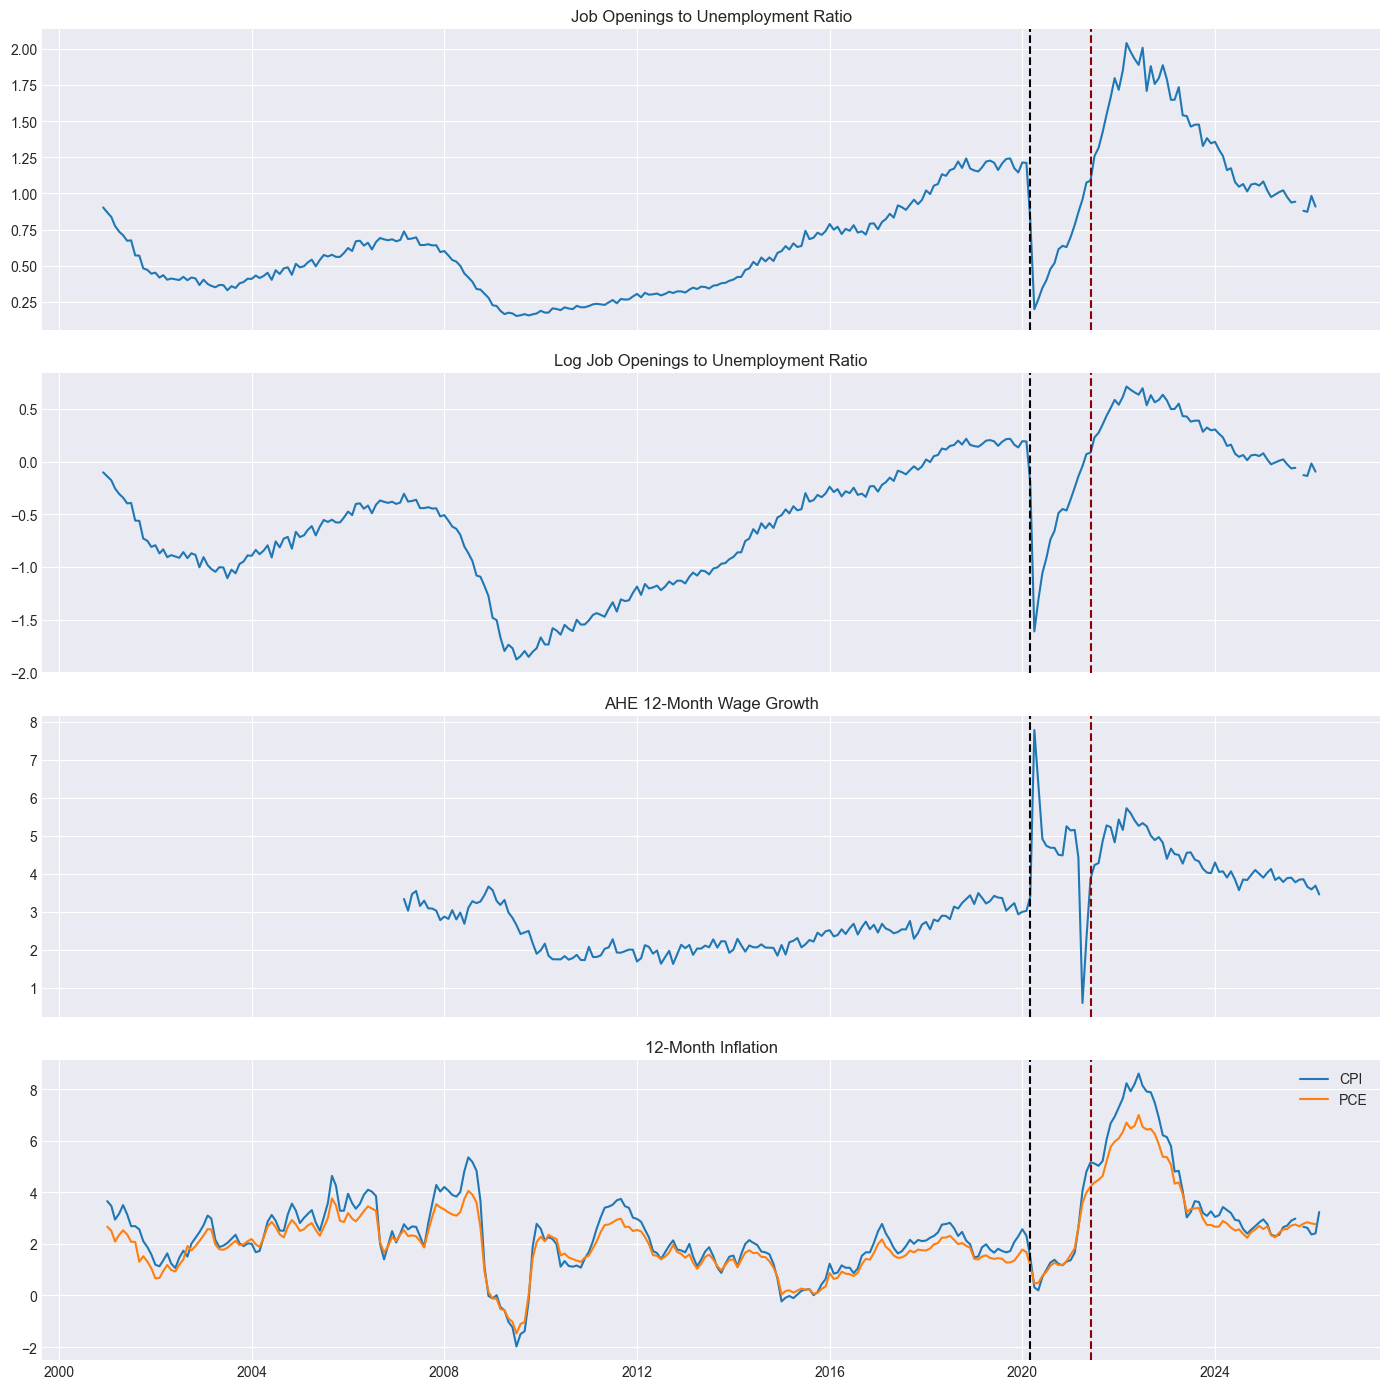

In [33]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

axes[0].plot(df["date"], df["jolts_ratio"], linewidth=1.5)
axes[0].axvline(candidate_break, color="black", linestyle="--")
axes[0].axvline(post_start, color="darkred", linestyle="--")
axes[0].set_title("Job Openings to Unemployment Ratio")

axes[1].plot(df["date"], df["log_jolts_ratio"], linewidth=1.5)
axes[1].axvline(candidate_break, color="black", linestyle="--")
axes[1].axvline(post_start, color="darkred", linestyle="--")
axes[1].set_title("Log Job Openings to Unemployment Ratio")

axes[2].plot(df["date"], df["ahe_12m_pct"], linewidth=1.5)
axes[2].axvline(candidate_break, color="black", linestyle="--")
axes[2].axvline(post_start, color="darkred", linestyle="--")
axes[2].set_title("AHE 12-Month Wage Growth")

axes[3].plot(df["date"], df["cpi_12m_pct"], linewidth=1.5, label="CPI")
axes[3].plot(df["date"], df["pce_12m_pct"], linewidth=1.5, label="PCE")
axes[3].axvline(candidate_break, color="black", linestyle="--")
axes[3].axvline(post_start, color="darkred", linestyle="--")
axes[3].set_title("12-Month Inflation")
axes[3].legend()

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_core_series.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

The overall conclusion from the plot is that the post-pandemic period is visually different from the pre-pandemic period. Labor tightness, wage growth, and inflation all shift upward after the pandemic shock. 

## Regime-Level Summary 

The job-openings-to-unemployment ratio averages 0.5594 before 2020, 0.6892 during the pandemic shock, and 1.3771 after June 2021. This is a huge change. The post-pandemic labor market is a lot tighter on average than the pre-pandemic labor market.


The log JOLTS ratio averages around -0.7140 before 2020, -0.4843 during the shock, and 0.2868 after June 2021. Moving from a negative average log ratio to a positive average log ratio means the balance between job openings and unemployed workers changed a drastically. The economy moved from a regime where unemployed workers generally exceeded job openings to a regime where openings were unusually high relative to unemployment. The quits rate also rises across regimes. Average 12-month wage growth rises from 2.48% before 2020 to 4.38% during the shock and 4.35%  post-pandemic. Higher quits are consistent with stronger worker bargaining power and a tighter labor market. The unemployment rate averages 5.88% before 2020, 7.52% during the pandemic shock, and 4.02%  post-pandemic. This confirms the unusual character of the post-pandemic labor market which **combines low unemployment with high job openings, making labor tightness unusually elevated.**

The post-pandemic period has higher labor tightness, higher quits, lower unemployment, higher wage growth, and higher inflation. This creates a strong reason to test whether predictive relationships changed.

In [34]:
regime_summary = (
    df.groupby("regime")[["jolts_ratio", "log_jolts_ratio", "quits_rate", "unemployment_rate", "ahe_12m_pct", "cpi_12m_pct", "pce_12m_pct"]]
    .agg(["count", "mean", "std", "min", "max"])
    .round(4)
)

regime_summary.to_csv(REPORT_ROOT / "03_regime_summary.csv")
regime_summary

jolts_ratio                             log_jolts_ratio                               quits_rate                             unemployment_rate                       \
                                   count   mean    std    min    max           count    mean    std     min    max      count   mean    std    min    max             count   mean    std    min   
regime                                                                                                                                                                                             
Pandemic Shock (2020-2021H1)          17 0.6892 0.3092 0.1995 1.2138              17 -0.4843 0.5165 -1.6118 0.1938         17 2.2059 0.3112 1.5000 2.7000                17 7.5176 3.1463 3.5000   
Post-Pandemic (2021-06+)              56 1.3771 0.3567 0.8730 2.0390              56  0.2868 0.2604 -0.1358 0.7124         57 2.3579 0.3530 1.9000 3.0000                57 4.0193 0.4775 3.4000   
Pre-2020                             229 0.5594 0.2841 0.1529 1.2419             229 -0.7140 0.5312 -1.8782 0.2166        229 1.9074 0.3000 1.2000 2.4000               240 5.8812 1.8095 3.5000   

                                     ahe_12m_pct                             cpi_12m_pct                              pce_12m_pct                               
                                 max       count   mean    std    min    max       count   mean    std     min    max       count   mean    std     min    max  
regime                                                                                                                                                          
Pandemic Shock (2020-2021H1) 14.8000          17 4.3808 1.6120 0.5974 7.7854          17 1.7319 1.2217  0.1980 4.8011          17 1.5849 0.9817  0.4614 3.9917  
Post-Pandemic (2021-06+)      5.9000          58 4.3543 0.5928 3.4566 5.7269          57 4.4440 2.0558  2.2988 8.5988          57 3.9168 1.5644  2.2356 6.9932  
Pre-2020                     10.0000         154 2.4821 0.5418 1.6261 3.6655         228 2.0802 1.2151 -1.9782 5.3517         228 1.7790 0.9713 -1.4769 4.0524

### Unit Root and Stationarity Checks

The Augmented Dickey-Fuller(ADF) test checks if a time series is stationary. A stationary series has behavior that is more stable over time, such as a relatively stable mean and variance. A nonstationary series can drift, trend, or behave differently across periods. Stationarity basically asks if the series behaves like it is moving around a stable long-run pattern or whether it keeps wandering in a way that makes historical relationships less dependable.

The null hypothesis of the ADF test is that the series has a unit root, meaning it is nonstationary. A small p-value gives proof against a unit root. A large p-value means the test doesn't reject nonstationarity. The ADF results show that the JOLTS ratio and log JOLTS ratio are not stationary in either the pre-pandemic or post-pandemic regimes. The pre-pandemic p-values are 0.6580 for the raw JOLTS ratio and 0.5493 for the log JOLTS ratio. The post-pandemic p-values are even higher, 0.9086 and 0.9363. This means labor tightness is highly persistent and doesn't behave like a stable stationary series within these regimes.

In [35]:
unit_rows = []

for col in ["jolts_ratio", "log_jolts_ratio", "ahe_12m_pct", "cpi_12m_pct", "pce_12m_pct"]:
    for label in [PRE_LABEL, SHOCK_LABEL, POST_LABEL]:
        use = df.loc[df["regime"] == label, col].dropna()

        if len(use) < 24:
            continue

        out = adfuller(use, autolag="AIC")
        unit_rows.append(
            {
                "col": col,
                "regime": label,
                "adf_stat": out[0],
                "p_value": out[1],
                "lags": out[2],
                "obs": out[3],
            }
        )

unit_data = pd.DataFrame(unit_rows)

unit_data.to_csv(REPORT_ROOT / "03_unit_root_tests.csv", index=False)
unit_data

,col,regime,adf_stat,p_value,lags,obs
0,jolts_ratio,Pre-2020,-1.2358,0.6580,11,217
1,jolts_ratio,Post-Pandemic (2021-06+),-0.4089,0.9086,2,53
2,log_jolts_ratio,Pre-2020,-1.4679,0.5493,11,217
3,log_jolts_ratio,Post-Pandemic (2021-06+),-0.2184,0.9363,2,53
4,ahe_12m_pct,Pre-2020,-1.0738,0.7254,13,140
5,ahe_12m_pct,Post-Pandemic (2021-06+),-0.7264,0.8398,2,55
6,cpi_12m_pct,Pre-2020,-2.5658,0.1003,15,212
7,cpi_12m_pct,Post-Pandemic (2021-06+),-2.7363,0.0680,7,49
8,pce_12m_pct,Pre-2020,-2.3672,0.1512,15,212
9,pce_12m_pct,Post-Pandemic (2021-06+),-3.0356,0.0317,9,47


### Level Shift Diagnostics

The mean_test function compares the average value of each core variable before March 2020 with the average value after June 2021. It uses Welch’s two-sample t-test, which doesn't assume equal variance across the two groups.

In [36]:
def mean_test(data, col, left_date, right_date):
    left = data.loc[data["date"] < left_date, col].dropna()
    right = data.loc[data["date"] >= right_date, col].dropna()

    test = stats.ttest_ind(left, right, equal_var=False, nan_policy="omit")

    return {
        "col": col,
        "left_date": left_date,
        "right_date": right_date,
        "mean_left": left.mean(),
        "mean_right": right.mean(),
        "diff": right.mean() - left.mean(),
        "t_stat": test.statistic,
        "p_value": test.pvalue,
        "n_left": len(left),
        "n_right": len(right),
    }

The level-shift table shows big changes across all core variables. The raw JOLTS ratio increases from 0.5651 to 1.3771. The log JOLTS ratio increases from -0.7061 to 0.2868. Average 12-month wage growth rises from 2.49%  to 4.35%, a difference of 1.87% points. CPI inflation rises from 2.08% to 4.44%, a difference of 2.36% points. PCE inflation rises from 1.78% to 3.92%, a difference of 2.14% points. All of these differences have p-values reported as 0. The p-values are effectively zero and the post-pandemic means are much higher. The mean shifts are statistically large and economically meaningful. This justifies treating post-pandemic observations as a distinct regime.

In [37]:
level_rows = []

for col in ["jolts_ratio", "log_jolts_ratio", "ahe_12m_pct", "cpi_12m_pct", "pce_12m_pct"]:
    level_rows.append(mean_test(df, col, candidate_break, post_start))

level_data = pd.DataFrame(level_rows)
level_data.to_csv(REPORT_ROOT / "03_level_shift_tests.csv", index=False)
level_data

,col,left_date,right_date,mean_left,mean_right,diff,t_stat,p_value,n_left,n_right
0,jolts_ratio,2020-03-01,2021-06-01,0.5651,1.3771,0.8120,-15.8213,0.0000,231,56
1,log_jolts_ratio,2020-03-01,2021-06-01,-0.7061,0.2868,0.9930,-20.0502,0.0000,231,56
2,ahe_12m_pct,2020-03-01,2021-06-01,2.4889,4.3543,1.8654,-20.9361,0.0000,156,58
3,cpi_12m_pct,2020-03-01,2021-06-01,2.0833,4.4440,2.3607,-8.3193,0.0000,230,57
4,pce_12m_pct,2020-03-01,2021-06-01,1.7785,3.9168,2.1383,-9.8632,0.0000,230,57


In [38]:
bench_rows = []

for label, part in [
    (PRE_LABEL, df[df["date"] < shock_start].copy()),
    (POST_LABEL, df[df["date"] >= post_start].copy()),
]:
    use, model = fit_model(part, "cpi_forward_12", ["unemployment_rate"], cov_lag=12)
    if model is not None:
        out = coef_table(model, "cpi_forward_12", label)
        out["model_name"] = "baseline_phillips"
        bench_rows.append(out)

phillips_data = pd.concat(bench_rows, axis=0).reset_index(drop=True)
phillips_data.to_csv(REPORT_ROOT / "03_phillips_benchmark.csv", index=False)

phillips_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,Pre-2020,cpi_forward_12,const,2.2862,0.5806,3.9376,0.0001,0.0040,-0.0002,240,baseline_phillips
1,Pre-2020,cpi_forward_12,unemployment_rate,-0.0421,0.0866,-0.4863,0.6267,0.0040,-0.0002,240,baseline_phillips
2,Post-Pandemic (2021-06+),cpi_forward_12,const,-5.9231,1.6367,-3.6189,0.0003,0.4769,0.4648,45,baseline_phillips
3,Post-Pandemic (2021-06+),cpi_forward_12,unemployment_rate,2.4813,0.4816,5.1523,0.0000,0.4769,0.4648,45,baseline_phillips


### Tightness Benchmark Regressions

In [39]:
base_rows = []

for y_col in ["wage_forward_3", "wage_forward_6", "wage_forward_12", "cpi_forward_3", "cpi_forward_6", "cpi_forward_12", "pce_forward_3", "pce_forward_6", "pce_forward_12"]:
    for label, part in [
        (PRE_LABEL, df[df["date"] < shock_start].copy()),
        (POST_LABEL, df[df["date"] >= post_start].copy()),
    ]:
        use, model = fit_model(part, y_col, ["log_jolts_ratio"], cov_lag=12)
        if model is not None:
            out = coef_table(model, y_col, label)
            out["model_name"] = "tightness_only"
            base_rows.append(out)

base_data = pd.concat(base_rows, axis=0).reset_index(drop=True)
base_data.to_csv(REPORT_ROOT / "03_tightness_only_results.csv", index=False)

base_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,Pre-2020,wage_forward_3,const,3.0473,0.1146,26.5867,0.0000,0.3221,0.3180,166,tightness_only
1,Pre-2020,wage_forward_3,log_jolts_ratio,0.7227,0.0830,8.7077,0.0000,0.3221,0.3180,166,tightness_only
2,Post-Pandemic (2021-06+),wage_forward_3,const,3.9181,0.1916,20.4540,0.0000,0.1565,0.1403,54,tightness_only
3,Post-Pandemic (2021-06+),wage_forward_3,log_jolts_ratio,1.2095,0.2950,4.0997,0.0000,0.1565,0.1403,54,tightness_only
4,Pre-2020,wage_forward_6,const,3.3696,0.2951,11.4183,0.0000,0.2788,0.2744,166,tightness_only
5,Pre-2020,wage_forward_6,log_jolts_ratio,1.0189,0.2569,3.9669,0.0001,0.2788,0.2744,166,tightness_only
6,Post-Pandemic (2021-06+),wage_forward_6,const,3.9058,0.1941,20.1211,0.0000,0.1764,0.1599,52,tightness_only
7,Post-Pandemic (2021-06+),wage_forward_6,log_jolts_ratio,1.0521,0.2852,3.6895,0.0002,0.1764,0.1599,52,tightness_only
8,Pre-2020,wage_forward_12,const,3.3846,0.2292,14.7686,0.0000,0.5454,0.5426,166,tightness_only
9,Pre-2020,wage_forward_12,log_jolts_ratio,1.0458,0.2025,5.1639,0.0000,0.5454,0.5426,166,tightness_only


## Persistence-Controlled Regressions

The persistence-controlled wage regressions add lagged 12-month wage growth as a control variable. This matters because wage growth can have momentum. If current labor tightness only appears predictive because tight labor markets happen during periods when wage growth is already high, then including lagged wage growth should weaken the tightness coefficient.

Before 2020, the log JOLTS ratio remains positive and statistically significant after controlling for lagged wage growth. The coefficient is 0.5187 for the 3-month horizon, 0.8185 for the 6-month horizon, and 0.8477 for the 12-month horizon. All three are statistically significant. Lagged wage growth is also positive and significant in the pre-pandemic models, with coefficients around 0.3896, 0.4384, and 0.4654. This means both labor tightness and wage persistence help explain future wage growth before the pandemic.

The model fit is strongest at the 12-month horizon. The pre-pandemic 12-month wage model has an R-squared of 0.6045, which is higher than the tightness-only wage model. This means adding wage persistence improves the model and confirms that wage dynamics are not fully captured by labor tightness alone.

After June 2021, the log JOLTS ratio remains positive. The coefficient is 2.1588 at the 3-month horizon, 1.8759 at the 6-month horizon, and 1.6198 at the 12-month horizon. The first two are statistically significant, while the 12-month coefficient is borderline with a p-value of 0.0517. Lagged wage growth is negative and statistically insignificant in all post-pandemic wage models.

This is an important result. It suggests that after the pandemic, past wage growth does not behave the same way as it did before the pandemic. The labor-tightness signal still has predictive value, especially at shorter horizons, but the overall model fit is weaker than in the pre-pandemic 12-month model. The post-pandemic R-squared values are around 0.19 to 0.22, much lower than the pre-pandemic 12-month value.

The conclusion is that labor tightness remains informative for future wage growth, but the wage equation becomes less stable after COVID-19. The next step is to evaluate whether this weaker post-pandemic fit also appears in out-of-sample forecasting performance.

Persistence-Controlled Inflation Regressions

The persistence-controlled inflation regressions add lagged 12-month inflation as a control. This is necessary because inflation is often persistent. The goal is to test whether the log JOLTS ratio adds information beyond what is already contained in current inflation.

For CPI inflation before 2020, the log JOLTS ratio remains statistically insignificant at all horizons. The p-values are 0.4788, 0.8585, and 0.8878 for the 3-, 6-, and 12-month horizons. The lagged CPI inflation variable is also not statistically significant. The R-squared values are low, ranging from 0.0035 to 0.0327. This means the pre-pandemic CPI forecasting equation has weak explanatory power in this simple specification.

After June 2021, the CPI models have higher R-squared values, around 0.18 to 0.22, but the log JOLTS ratio is still not statistically significant after controlling for inflation persistence. The post-pandemic 3-month coefficient is 0.4362 with a p-value of 0.8353. The 6-month coefficient becomes negative at -1.9010, with a p-value of 0.4121. The 12-month coefficient is -4.1934, with a p-value of 0.2561. These results suggest that once inflation persistence is included, the post-pandemic CPI signal from labor tightness is not reliable.

For PCE inflation before 2020, the log JOLTS ratio is also statistically insignificant at all horizons. The coefficients are small or negative, and the R-squared values are close to zero. This confirms that labor tightness did not provide a strong pre-pandemic PCE inflation signal in this simple model.

After June 2021, PCE inflation behaves differently. Lagged PCE inflation is strongly predictive at all horizons, with coefficients of 0.9282, 1.0836, and 1.0358, and p-values of 0.0037, 0.0070, and 0.0326. The log JOLTS ratio is negative in the post-pandemic PCE models. It is not significant at 3 months, significant at 6 months with a coefficient of -3.9793 and p-value of 0.0400, and marginal at 12 months with a coefficient of -5.5048 and p-value of 0.0888.

This does not mean higher labor tightness mechanically lowers inflation. It likely reflects the post-pandemic timing problem: tightness peaked before inflation fully normalized, and inflation persistence carried much of the forecast information. In a short post-pandemic sample, a negative coefficient can emerge because tightness was falling while lagged inflation remained high or because the model is trying to separate two highly regime-dependent processes.

The main conclusion is that labor tightness is much more robust for wage forecasting than inflation forecasting. For inflation, persistence matters more than labor tightness once the model controls for lagged inflation. The next step should be out-of-sample model comparison against simple inflation persistence benchmarks.

In [40]:
wage_rows = []

for horizon in [3, 6, 12]:
    y_col = f"wage_forward_{horizon}"
    x_cols = ["log_jolts_ratio", "ahe_12m_pct_lag_1"]

    for label, part in [
        (PRE_LABEL, df[df["date"] < shock_start].copy()),
        (POST_LABEL, df[df["date"] >= post_start].copy()),
    ]:
        use, model = fit_model(part, y_col, x_cols, cov_lag=12)
        if model is not None:
            out = coef_table(model, y_col, label)
            out["model_name"] = "wage_persist"
            out["horizon"] = horizon
            wage_rows.append(out)

wage_data = pd.concat(wage_rows, axis=0).reset_index(drop=True)
wage_data.to_csv(REPORT_ROOT / "03_wage_predictive_results.csv", index=False)

wage_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name,horizon
0,Pre-2020,wage_forward_3,const,1.8803,0.3344,5.6222,0.0000,0.3822,0.3740,153,wage_persist,3
1,Pre-2020,wage_forward_3,log_jolts_ratio,0.5187,0.0835,6.2089,0.0000,0.3822,0.3740,153,wage_persist,3
2,Pre-2020,wage_forward_3,ahe_12m_pct_lag_1,0.3896,0.1303,2.9909,0.0028,0.3822,0.3740,153,wage_persist,3
3,Post-Pandemic (2021-06+),wage_forward_3,const,5.6091,1.5097,3.7153,0.0002,0.1947,0.1631,54,wage_persist,3
4,Post-Pandemic (2021-06+),wage_forward_3,log_jolts_ratio,2.1588,0.8909,2.4231,0.0154,0.1947,0.1631,54,wage_persist,3
5,Post-Pandemic (2021-06+),wage_forward_3,ahe_12m_pct_lag_1,-0.4507,0.3717,-1.2125,0.2253,0.1947,0.1631,54,wage_persist,3
6,Pre-2020,wage_forward_6,const,2.1085,0.3958,5.3274,0.0000,0.2994,0.2900,153,wage_persist,6
7,Pre-2020,wage_forward_6,log_jolts_ratio,0.8185,0.2188,3.7404,0.0002,0.2994,0.2900,153,wage_persist,6
8,Pre-2020,wage_forward_6,ahe_12m_pct_lag_1,0.4384,0.1657,2.6462,0.0081,0.2994,0.2900,153,wage_persist,6
9,Post-Pandemic (2021-06+),wage_forward_6,const,5.2826,1.4649,3.6061,0.0003,0.2175,0.1856,52,wage_persist,6


In [41]:
inflation_rows = []

for prefix in ["cpi", "pce"]:
    for horizon in [3, 6, 12]:
        y_col = f"{prefix}_forward_{horizon}"
        x_cols = ["log_jolts_ratio", f"{prefix}_12m_pct_lag_1"]

        for label, part in [
            (PRE_LABEL, df[df["date"] < shock_start].copy()),
            (POST_LABEL, df[df["date"] >= post_start].copy()),
        ]:
            use, model = fit_model(part, y_col, x_cols, cov_lag=12)
            if model is not None:
                out = coef_table(model, y_col, label)
                out["model_name"] = f"{prefix}_persist"
                out["horizon"] = horizon
                inflation_rows.append(out)

inflation_data = pd.concat(inflation_rows, axis=0).reset_index(drop=True)
inflation_data.to_csv(REPORT_ROOT / "03_inflation_predictive_results.csv", index=False)
inflation_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name,horizon
0,Pre-2020,cpi_forward_3,const,3.0732,0.9949,3.0891,0.0020,0.0327,0.0240,227,cpi_persist,3
1,Pre-2020,cpi_forward_3,log_jolts_ratio,0.3574,0.5047,0.7083,0.4788,0.0327,0.0240,227,cpi_persist,3
2,Pre-2020,cpi_forward_3,cpi_12m_pct_lag_1,-0.3763,0.3612,-1.0418,0.2975,0.0327,0.0240,227,cpi_persist,3
3,Post-Pandemic (2021-06+),cpi_forward_3,const,1.5522,0.8650,1.7945,0.0727,0.2211,0.1893,52,cpi_persist,3
4,Post-Pandemic (2021-06+),cpi_forward_3,log_jolts_ratio,0.4362,2.0982,0.2079,0.8353,0.2211,0.1893,52,cpi_persist,3
5,Post-Pandemic (2021-06+),cpi_forward_3,cpi_12m_pct_lag_1,0.5373,0.3323,1.6172,0.1058,0.2211,0.1893,52,cpi_persist,3
6,Pre-2020,cpi_forward_6,const,2.4841,0.7969,3.1173,0.0018,0.0191,0.0103,227,cpi_persist,6
7,Pre-2020,cpi_forward_6,log_jolts_ratio,0.0737,0.4133,0.1782,0.8585,0.0191,0.0103,227,cpi_persist,6
8,Pre-2020,cpi_forward_6,cpi_12m_pct_lag_1,-0.2130,0.3106,-0.6857,0.4929,0.0191,0.0103,227,cpi_persist,6
9,Post-Pandemic (2021-06+),cpi_forward_6,const,1.4409,1.0049,1.4339,0.1516,0.2079,0.1749,51,cpi_persist,6


## Interaction Models for Post-Break Slope Change

The interaction models test whether the slope on labor tightness changes in the post-pandemic regime. The variable post_regime allows the intercept to shift after June 2021. The variable jolts_x_post allows the coefficient on the log JOLTS ratio to change after June 2021. If jolts_x_post is statistically significant, the relationship between tightness and the target variable differs in the post-pandemic regime.

For wage growth, the interaction results show that the full-sample log JOLTS ratio is positive and significant at all horizons. The 3-month coefficient is 1.5037, the 6-month coefficient is 1.2204, and the 12-month coefficient is 1.0458. This confirms that labor tightness has a positive wage-growth relationship in the full sample.

The post-pandemic interaction term is not significant at the 3-month or 6-month wage horizons. However, it is negative and significant at the 12-month wage horizon. The 12-month jolts_x_post coefficient is -1.3256, with a p-value of 0.0328. This means the 12-month relationship between labor tightness and future wage growth weakens in the post-pandemic period. The labor-tightness signal does not disappear, but its medium-horizon slope changes.

For CPI inflation, the post-pandemic interaction is significant at the 3-month horizon and marginal at the 6-month horizon. The 3-month interaction coefficient is 6.3140, with a p-value of 0.0279. The 6-month interaction coefficient is 4.2011, with a p-value of 0.0876. The 12-month interaction is not significant. This suggests that the post-pandemic period strengthened the short-horizon relationship between labor tightness and CPI inflation, but the effect is not stable across longer horizons.

For PCE inflation, the post-pandemic interaction is marginal at the 3-month horizon, with a coefficient of 3.6747 and p-value of 0.0713, but it is not significant at the 6-month or 12-month horizons. The PCE results therefore provide weaker interaction evidence than CPI.

The main conclusion from the interaction models is that the post-pandemic shift is target-specific and horizon-specific. The wage equation shows evidence of a weaker 12-month tightness slope after the break. CPI shows evidence of a stronger short-run post-pandemic tightness-inflation association. PCE shows only weak short-run evidence. This supports the project’s central claim that labor-market signals became regime-dependent rather than uniformly useless.

In [42]:
interaction_rows = []

for y_col, lag_col in [
    ("wage_forward_3", "ahe_12m_pct_lag_1"),
    ("wage_forward_6", "ahe_12m_pct_lag_1"),
    ("wage_forward_12", "ahe_12m_pct_lag_1"),
    ("cpi_forward_3", "cpi_12m_pct_lag_1"),
    ("cpi_forward_6", "cpi_12m_pct_lag_1"),
    ("cpi_forward_12", "cpi_12m_pct_lag_1"),
    ("pce_forward_3", "pce_12m_pct_lag_1"),
    ("pce_forward_6", "pce_12m_pct_lag_1"),
    ("pce_forward_12", "pce_12m_pct_lag_1"),
]:
    use = df[["date", y_col, "log_jolts_ratio", "post_regime", lag_col]].dropna().copy()
    use["jolts_x_post"] = use["log_jolts_ratio"] * use["post_regime"]

    x = sm.add_constant(use[["log_jolts_ratio", "post_regime", "jolts_x_post", lag_col]])
    y = use[y_col]
    model = sm.OLS(y, x).fit(cov_type="HAC", cov_kwds={"maxlags": 12})

    out = coef_table(model, y_col, "full_sample")
    out["model_name"] = "interaction_post"
    interaction_rows.append(out)

interaction_data = pd.concat(interaction_rows, axis=0).reset_index(drop=True)
interaction_data.to_csv(REPORT_ROOT / "03_interaction_results.csv", index=False)
interaction_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,full_sample,wage_forward_3,const,3.8301,1.2533,3.0560,0.0022,0.2388,0.2249,224,interaction_post
1,full_sample,wage_forward_3,log_jolts_ratio,1.5037,0.7139,2.1062,0.0352,0.2388,0.2249,224,interaction_post
2,full_sample,wage_forward_3,post_regime,0.1531,0.4697,0.3260,0.7444,0.2388,0.2249,224,interaction_post
3,full_sample,wage_forward_3,jolts_x_post,-0.2577,0.5415,-0.4759,0.6341,0.2388,0.2249,224,interaction_post
4,full_sample,wage_forward_3,ahe_12m_pct_lag_1,-0.0173,0.2590,-0.0670,0.9466,0.2388,0.2249,224,interaction_post
5,full_sample,wage_forward_6,const,3.0228,0.7283,4.1505,0.0000,0.4462,0.4360,222,interaction_post
6,full_sample,wage_forward_6,log_jolts_ratio,1.2204,0.4318,2.8266,0.0047,0.4462,0.4360,222,interaction_post
7,full_sample,wage_forward_6,post_regime,0.0658,0.3639,0.1807,0.8566,0.4462,0.4360,222,interaction_post
8,full_sample,wage_forward_6,jolts_x_post,-0.6572,0.5088,-1.2916,0.1965,0.4462,0.4360,222,interaction_post
9,full_sample,wage_forward_6,ahe_12m_pct_lag_1,0.2207,0.1458,1.5138,0.1301,0.4462,0.4360,222,interaction_post


## Equations for Forecasting

This section prepares the forecasting equations that will be tested for structural instability. The wage equations use log labor tightness and lagged wage growth. The CPI equations use log labor tightness and lagged CPI inflation. The PCE equations use log labor tightness and lagged PCE inflation. This structure is intentionally simple. It keeps the focus on whether labor tightness adds predictive content beyond persistence.

The simplicity is useful for interpretability. A more complex model may forecast better, but it is harder to interpret when the research question is about the stability of a specific labor-market signal. This notebook therefore uses these equations as transparent structural benchmarks before moving to broader forecasting models.

### Chow Tests on Forecasting Equations

The Chow test results directly test whether the forecasting equations break at March 2020 and June 2021. The null hypothesis is that the same regression relationship holds on both sides of the break date. A small p-value means the model fits better when the sample is split, which suggests a structural break.

For wage growth, the March 2020 break is statistically significant at all horizons. The p-values are 0.0074 for 3-month wage growth, 0.0121 for 6-month wage growth, and effectively zero for 12-month wage growth. This indicates that the pandemic shock changed the wage forecasting equation.

The June 2021 break is not significant for 3-month or 6-month wage growth, with p-values of 0.9312 and 0.4100. However, it is significant for 12-month wage growth, with a p-value of 0.0001. This means the initial pandemic shock affected wage relationships broadly, while the post-pandemic stabilization break is most important for the longer wage horizon.

For CPI inflation, both March 2020 and June 2021 break tests are statistically significant at all horizons. The F-statistics are large, especially for 12-month CPI at the March 2020 break, where the F-statistic is 39.4477. The p-values are effectively zero. This is strong evidence that CPI forecasting relationships changed around the pandemic and reopening period.

For PCE inflation, the pattern is also strong. All March 2020 and June 2021 Chow tests are statistically significant. The largest result is for 12-month PCE inflation at the March 2020 break, with an F-statistic of 48.7276 and p-value effectively zero. This suggests substantial instability in the PCE forecasting equation.

The conclusion is that the forecasting equations are not stable across the pandemic and post-pandemic regimes. This is one of the strongest pieces of evidence in the notebook. It supports the project’s core premise that traditional labor-market forecasting relationships cannot be assumed stable after COVID-19.

The main weakness is that Chow tests require the break date to be specified in advance. They show that March 2020 and June 2021 are important candidate breaks, but they do not prove these are the only or exact break dates. That is why the next section uses a sup-F style break search.

In [43]:
break_rows = []

for y_col, x_cols in [
    ("wage_forward_3", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_6", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("cpi_forward_3", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_6", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("pce_forward_3", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_6", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
]:
    out_one = chow_test(df, y_col, x_cols, candidate_break)
    out_two = chow_test(df, y_col, x_cols, post_start)

    if out_one is not None:
        out_one["test_name"] = "chow_2020_03"
        break_rows.append(out_one)

    if out_two is not None:
        out_two["test_name"] = "chow_2021_06"
        break_rows.append(out_two)

break_data = pd.DataFrame(break_rows)
break_data

,y_col,break_date,f_stat,p_value,n_left,n_right,k,test_name
0,wage_forward_3,2020-03-01,4.0967,0.0074,155,69,3,chow_2020_03
1,wage_forward_3,2021-06-01,0.1475,0.9312,170,54,3,chow_2021_06
2,wage_forward_6,2020-03-01,3.7289,0.0121,155,67,3,chow_2020_03
3,wage_forward_6,2021-06-01,0.9653,0.4100,170,52,3,chow_2021_06
4,wage_forward_12,2020-03-01,10.0999,0.0000,155,61,3,chow_2020_03
5,wage_forward_12,2021-06-01,7.8320,0.0001,170,46,3,chow_2021_06
6,cpi_forward_3,2020-03-01,12.8188,0.0000,229,67,3,chow_2020_03
7,cpi_forward_3,2021-06-01,10.0030,0.0000,244,52,3,chow_2021_06
8,cpi_forward_6,2020-03-01,19.8498,0.0000,229,66,3,chow_2020_03
9,cpi_forward_6,2021-06-01,11.3161,0.0000,244,51,3,chow_2021_06


### Sup-F Style Break Search

The sup-F break search looks for the break date that produces the largest Chow-style F-statistic. This allows the data to identify the strongest break rather than forcing the break to be March 2020 or June 2021.

For wage growth, the strongest break dates are clustered before or near the pandemic. The 3-month wage equation has its strongest break in December 2019, the 6-month equation in October 2019, and the 12-month equation in April 2019. All have p-values effectively equal to zero. This suggests that wage-forecasting instability may have started before the official pandemic shock, possibly because the labor market was already very tight in 2018 and 2019 or because the forward targets overlap with the pandemic period.

For CPI inflation, the strongest breaks differ by horizon. The 3-month CPI equation has a strongest break in May 2010, and the 6-month equation in August 2009. These dates likely reflect the aftermath of the Great Recession and the transition into the low-inflation 2010s. The 12-month CPI equation has its strongest break in June 2020, directly connected to the pandemic inflation regime.

For PCE inflation, the 3-month equation has its strongest break in December 2009, while the 6-month and 12-month equations break in October 2020 and August 2020. This indicates that short-horizon inflation relationships were affected by the Great Recession period, while longer-horizon inflation relationships broke most strongly around the COVID period.

The conclusion is that structural instability is real, but it is not always located at the same date. Wage equations appear to show instability around 2019, while medium-horizon and long-horizon inflation equations show stronger COVID-era breaks. This makes the project more nuanced. The result is not simply “COVID changed everything on one date.” The better interpretation is that different forecasting relationships became unstable at different times, depending on the target and forecast horizon.

The main limitation is that the sup-F implementation is exploratory. Because it searches over many possible break dates, the reported p-values should not be treated as exact final inference. In the final submission, this section should be described as breakpoint screening evidence, and the final forecasting notebook should test whether models trained before these breakpoints perform poorly afterward.

In [44]:
sup_rows = []

for y_col, x_cols in [
    ("wage_forward_3", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_6", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("cpi_forward_3", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_6", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("pce_forward_3", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_6", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
    ("pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
]:
    best, path = sup_f_test(df, y_col, x_cols, trim_pct=0.15)
    if best is not None:
        best["test_name"] = "sup_f"
        sup_rows.append(best)

sup_data = pd.DataFrame(sup_rows)
sup_data.to_csv(REPORT_ROOT / "03_sup_f_results.csv", index=False)

sup_data

,y_col,break_date,f_stat,p_value,n_left,n_right,k,test_name
0,wage_forward_3,2019-12-01,18.4112,0.0000,152,72,3,sup_f
1,wage_forward_6,2019-10-01,27.5730,0.0000,150,72,3,sup_f
2,wage_forward_12,2019-04-01,43.4986,0.0000,144,72,3,sup_f
3,cpi_forward_3,2010-05-01,24.0818,0.0000,111,185,3,sup_f
4,cpi_forward_6,2009-08-01,24.9494,0.0000,102,193,3,sup_f
5,cpi_forward_12,2020-06-01,43.2772,0.0000,232,57,3,sup_f
6,pce_forward_3,2009-12-01,23.1202,0.0000,106,191,3,sup_f
7,pce_forward_6,2020-10-01,31.6475,0.0000,236,59,3,sup_f
8,pce_forward_12,2020-08-01,54.0817,0.0000,234,55,3,sup_f


## Forward Correlation Across Horizons

The forward-correlation table measures the raw correlation between the log JOLTS ratio and future wage, CPI, and PCE outcomes at 3-, 6-, and 12-month horizons. Correlation ranges from -1 to 1. A positive value means higher labor tightness is associated with higher future wage growth or inflation. A negative value means higher labor tightness is associated with lower future outcomes. A value near zero means little linear association.

For wage growth, the correlations are positive in every regime and at every horizon. In the full sample, the correlation rises from 0.4880 at 3 months to 0.7619 at 12 months. Before 2020, the correlation is 0.5675 at 3 months, 0.5280 at 6 months, and 0.7385 at 12 months. During the pandemic shock, the correlations are very high, ranging from 0.8398 to 0.9128, but those should be interpreted cautiously because the shock sample is short and unusual. Post-pandemic wage correlations remain positive but weaker, around 0.3857 to 0.4199.

This supports the conclusion that labor tightness remains informative for wage growth, but the post-pandemic relationship is weaker than the pre-pandemic 12-month relationship.

For CPI inflation, the pre-pandemic correlations are close to zero or slightly negative. They are 0.0424, -0.0010, and -0.0325 across the three horizons. This means labor tightness had little raw pre-pandemic relationship with future CPI inflation. Post-pandemic correlations are positive, especially at the 3-month horizon, where the correlation is 0.4283. The correlation declines to 0.3517 at 6 months and 0.1839 at 12 months. This means the post-pandemic tightness-inflation association is strongest at shorter horizons.

For PCE inflation, the pre-pandemic correlations are also close to zero or negative. The post-pandemic correlations are positive, with 0.4507 at 3 months, 0.3561 at 6 months, and 0.1823 at 12 months. This matches the CPI pattern and suggests that post-pandemic labor tightness is more related to near-term inflation than to 12-month-ahead inflation.

The forward-correlation plot visualizes these findings. The x-axis shows forecast horizons of 3, 6, and 12 months. The y-axis shows the correlation between log labor tightness and the future outcome. The wage panel shows positive correlations across all regimes, with the post-pandemic line below the pandemic-shock line and below the strongest pre-pandemic 12-month relationship. The CPI and PCE panels show that the pre-pandemic inflation relationship is near zero, while the post-pandemic relationship is clearly positive at shorter horizons and fades at longer horizons.

The conclusion is that labor tightness is a stable directional signal for wages but not for inflation. For inflation, the signal appears to be newly positive in the post-pandemic period, especially at short horizons. This supports the project’s claim that the informational content of labor-market indicators changed after COVID-19.

In [45]:
wage_corr = forward_corr(df, "log_jolts_ratio", "wage", [3, 6, 12])
cpi_corr = forward_corr(df, "log_jolts_ratio", "cpi", [3, 6, 12])
pce_corr = forward_corr(df, "log_jolts_ratio", "pce", [3, 6, 12])

lead_data = pd.concat([wage_corr, cpi_corr, pce_corr], axis=0).reset_index(drop=True)
lead_data.to_csv(REPORT_ROOT / "03_forward_correlation.csv", index=False)

lead_data

,y_col,horizon,corr_all,corr_pre,corr_shock,corr_post
0,wage,3,0.4880,0.5675,0.8398,0.3956
1,wage,6,0.6549,0.5280,0.9128,0.4199
2,wage,12,0.7619,0.7385,0.8548,0.3857
3,cpi,3,0.2192,0.0424,-0.2566,0.4283
4,cpi,6,0.2533,-0.0010,0.0228,0.3517
5,cpi,12,0.2486,-0.0325,0.0468,0.1839
6,pce,3,0.2456,-0.0029,-0.1146,0.4507
7,pce,6,0.2666,-0.0576,0.1183,0.3561
8,pce,12,0.2486,-0.1068,0.0618,0.1823


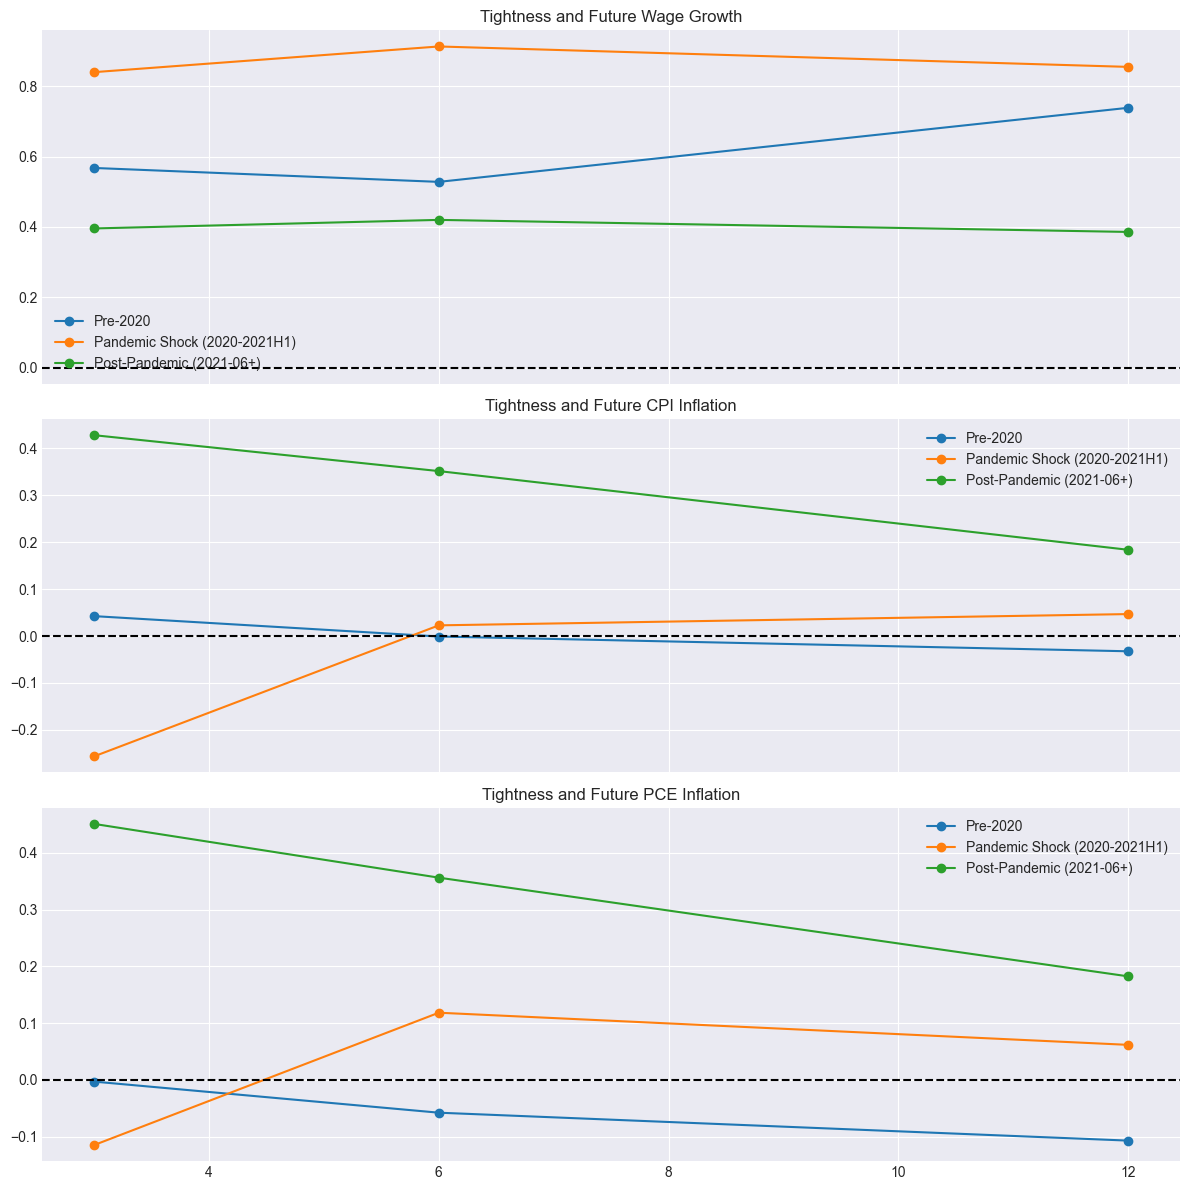

In [46]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for label, col in [("corr_pre", PRE_LABEL), ("corr_shock", SHOCK_LABEL), ("corr_post", POST_LABEL)]:
    axes[0].plot(wage_corr["horizon"], wage_corr[label], marker="o", linewidth=1.5, label=col)
    axes[1].plot(cpi_corr["horizon"], cpi_corr[label], marker="o", linewidth=1.5, label=col)
    axes[2].plot(pce_corr["horizon"], pce_corr[label], marker="o", linewidth=1.5, label=col)

axes[0].set_title("Tightness and Future Wage Growth")
axes[1].set_title("Tightness and Future CPI Inflation")
axes[2].set_title("Tightness and Future PCE Inflation")

for ax in axes:
    ax.axhline(0, color="black", linestyle="--")
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_forward_correlation.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## Rolling Regressions 

Rolling regressions estimate the same model over a moving 60-month window. This means each coefficient is estimated using only the most recent five years of data at each date. The output is a time series of coefficients. This method is useful because it shows whether the estimated relationship is stable or whether it changes over time.

A stable forecasting relationship should produce rolling coefficients that move gradually and remain in a consistent range. A fragile relationship will show coefficients that spike, collapse, change sign, or behave differently around crisis periods. Rolling regressions are especially useful here because the project is about regime instability.

### Wage Prediction

The wage rolling-regression plot shows the coefficient on the log JOLTS ratio in wage forecasting equations at the 3-, 6-, and 12-month horizons. The y-axis is the estimated coefficient on labor tightness. The x-axis is time. The dashed horizontal line at zero shows where labor tightness has no estimated relationship with future wage growth. The black vertical line marks March 2020, and the dark red vertical line marks June 2021.

The 3-month wage coefficient is mostly positive, rises sharply around the pandemic shock, remains elevated through the early post-pandemic period, and then declines toward later years. The spike around 2020 suggests that short-horizon wage-growth relationships were heavily distorted by the pandemic period, likely because wage growth was affected by employment composition and rapid labor-market adjustment.

The 6-month wage coefficient follows a similar pattern but is somewhat smoother. It rises strongly into the pandemic period and then gradually declines. This suggests that labor tightness remained positively related to wage growth, but the estimated strength of the relationship was not stable.

The 12-month wage coefficient is the smoothest. It rises during the late 2010s and early pandemic period, then declines substantially after 2021 before stabilizing at a lower positive level. This matches the regression evidence that the 12-month wage relationship weakened after the post-pandemic break.

The conclusion is that labor tightness remains positively associated with wage growth, but the coefficient is time-varying. The relationship is not stable enough to support one fixed full-sample wage equation without regime controls or rolling evaluation.

In [47]:
roll_wage_3 = rolling_model(df, "wage_forward_3", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], window=60, cov_lag=12)
roll_wage_6 = rolling_model(df, "wage_forward_6", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], window=60, cov_lag=12)
roll_wage_12 = rolling_model(df, "wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], window=60, cov_lag=12)

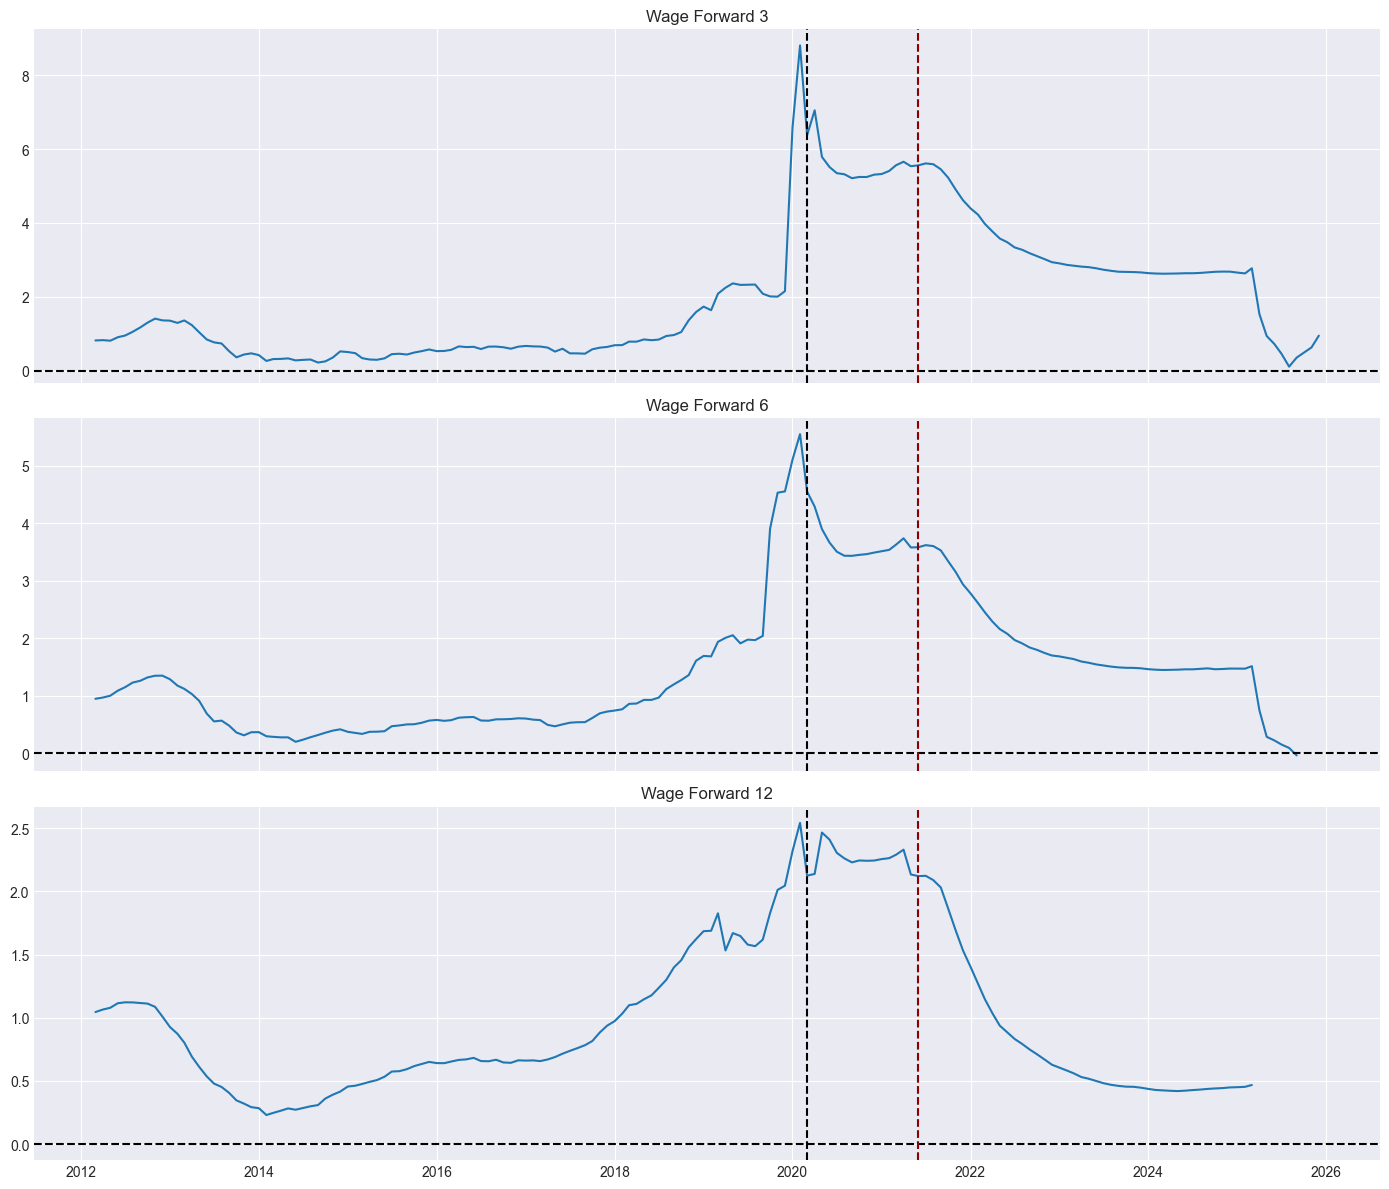

In [48]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for roll, title, ax in [
    (roll_wage_3, "Wage Forward 3", axes[0]),
    (roll_wage_6, "Wage Forward 6", axes[1]),
    (roll_wage_12, "Wage Forward 12", axes[2]),
]:
    ax.plot(roll["date"], roll["coef_log_jolts_ratio"], linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(candidate_break, color="black", linestyle="--")
    ax.axvline(post_start, color="darkred", linestyle="--")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_rolling_wage_coef.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Rolling Inflation Prediction

The inflation rolling-regression plot shows the coefficient on the log JOLTS ratio in CPI and PCE forecasting equations. The left column contains CPI results, and the right column contains PCE results. The rows represent 3-, 6-, and 12-month horizons.

The CPI coefficients are unstable and change sign across time. Before 2020, the coefficients move through positive and negative periods, which is consistent with the weak pre-pandemic inflation regressions. Around the pandemic and post-pandemic periods, the coefficients shift sharply. At some horizons they become strongly negative after 2021. This instability means the CPI relationship is not a reliable fixed linear relationship.

The PCE coefficients show similar instability. The 3-month and 6-month PCE coefficients move substantially over time, and the 12-month coefficient also shows large swings. The post-pandemic decline into negative territory is consistent with the persistence-controlled regressions, where labor tightness becomes negative once lagged PCE inflation is included.

The main conclusion is that labor tightness is not a stable inflation predictor across the full sample. Inflation forecasting relationships are more regime-sensitive than wage forecasting relationships. The next forecasting notebook should therefore evaluate inflation models out of sample and compare them against persistence benchmarks, because in-sample coefficient significance is not enough.

In [49]:
roll_cpi_3 = rolling_model(df, "cpi_forward_3", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], window=60, cov_lag=12)
roll_cpi_6 = rolling_model(df, "cpi_forward_6", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], window=60, cov_lag=12)
roll_cpi_12 = rolling_model(df, "cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], window=60, cov_lag=12)

roll_pce_3 = rolling_model(df, "pce_forward_3", ["log_jolts_ratio", "pce_12m_pct_lag_1"], window=60, cov_lag=12)
roll_pce_6 = rolling_model(df, "pce_forward_6", ["log_jolts_ratio", "pce_12m_pct_lag_1"], window=60, cov_lag=12)
roll_pce_12 = rolling_model(df, "pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"], window=60, cov_lag=12)

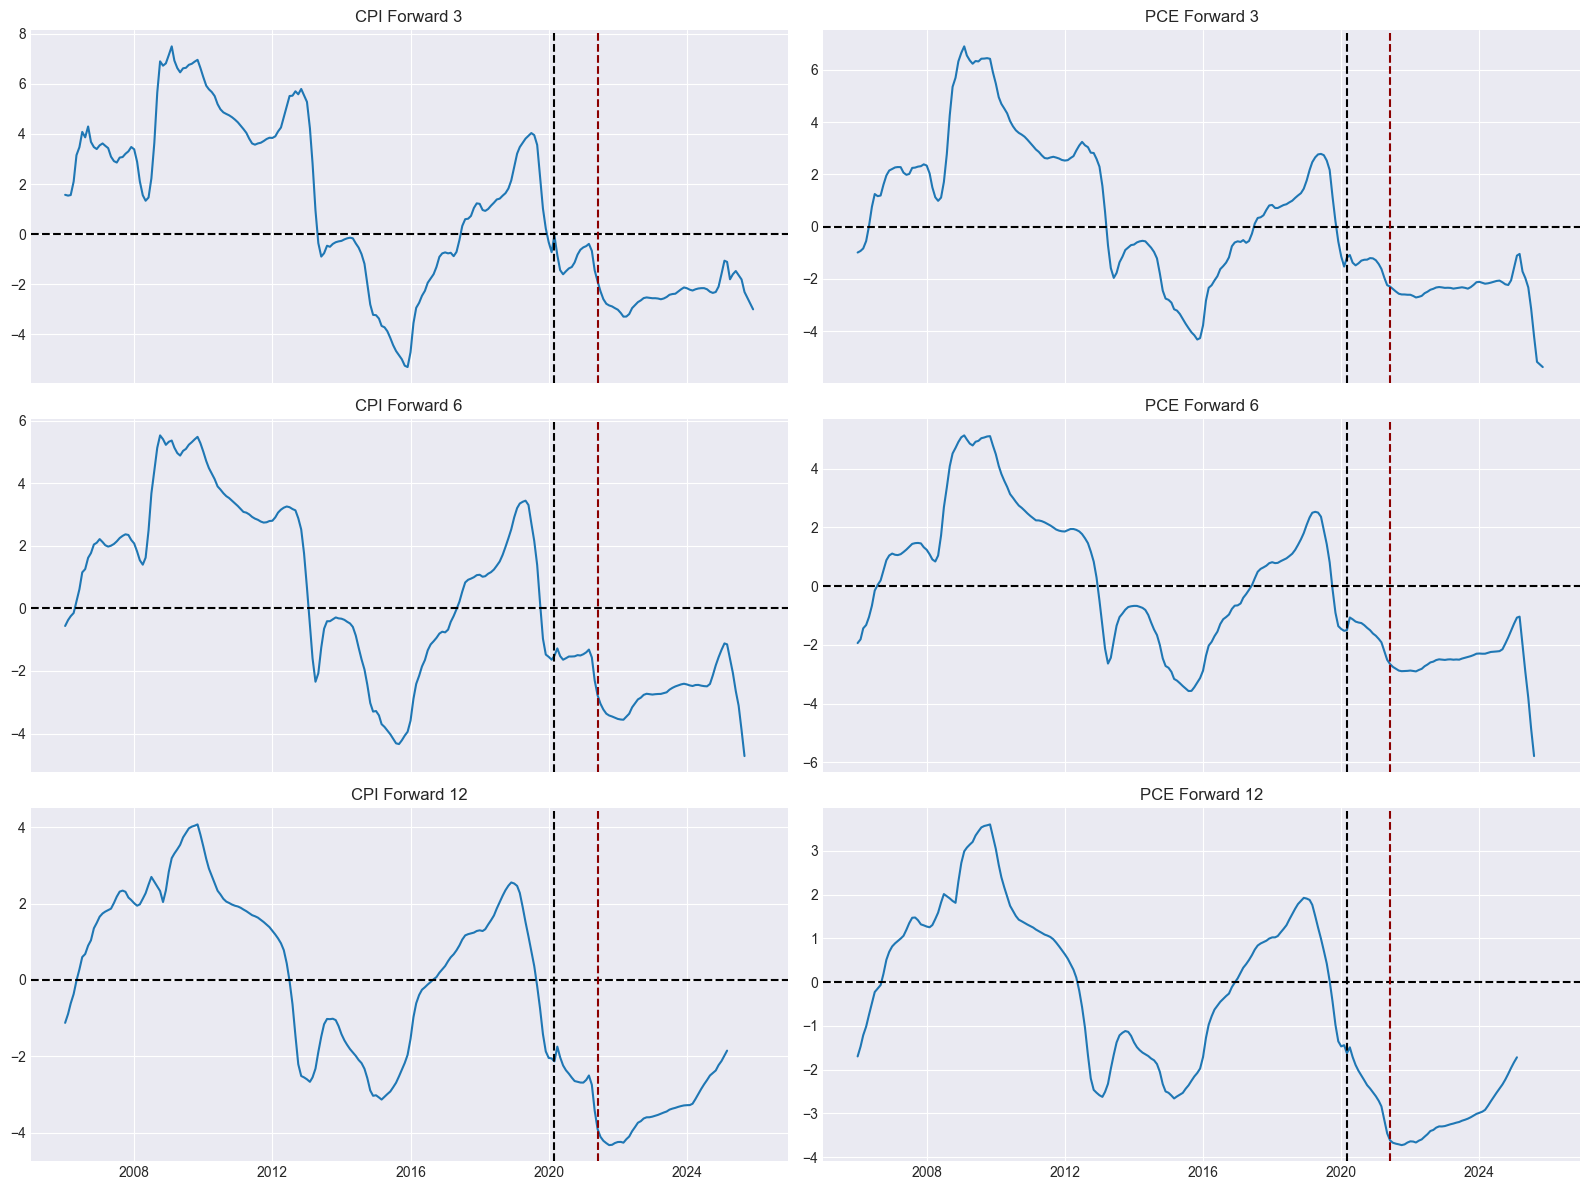

In [50]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)

for roll, title, ax in [
    (roll_cpi_3, "CPI Forward 3", axes[0, 0]),
    (roll_cpi_6, "CPI Forward 6", axes[1, 0]),
    (roll_cpi_12, "CPI Forward 12", axes[2, 0]),
    (roll_pce_3, "PCE Forward 3", axes[0, 1]),
    (roll_pce_6, "PCE Forward 6", axes[1, 1]),
    (roll_pce_12, "PCE Forward 12", axes[2, 1]),
]:
    ax.plot(roll["date"], roll["coef_log_jolts_ratio"], linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(candidate_break, color="black", linestyle="--")
    ax.axvline(post_start, color="darkred", linestyle="--")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_rolling_inflation_coef.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## CUSUM Stability on the Forecasting Equation

The CUSUM test checks whether a regression model’s residuals remain stable over time. Residuals are the model’s errors, meaning the difference between actual outcomes and fitted values. If a model relationship is stable, residuals should fluctuate around zero without a persistent drift. If residuals accumulate in one direction for a long period, that suggests the model is systematically overpredicting or underpredicting, which can indicate a structural break.

The CUSUM table reports the test statistic, p-value, critical values, and number of observations for the 12-month wage, CPI, and PCE forecasting equations. The null hypothesis is model stability. A small p-value rejects stability.

The wage equation has a CUSUM statistic of 2.3357, which exceeds the 1 percent critical value of 1.6300, and the p-value is 0.0000. This rejects stability for the 12-month wage equation. The CPI equation has a statistic of 2.9238, and the PCE equation has a statistic of 3.1032, both far above the critical values with p-values of 0.0000. This is strong evidence that all three 12-month forecasting equations are unstable over time.

The CUSUM path plot shows the cumulative standardized residual path for each equation. The wage CUSUM path drifts downward through the 2010s, reverses sharply around the pandemic, rises strongly into 2021–2022, and then gradually returns toward zero. This means the wage model made persistent errors before the pandemic and then experienced a sharp post-pandemic reversal.

The CPI CUSUM path rises before the financial crisis, falls for much of the 2010s, drops sharply around 2020, and then rebounds after 2021. This pattern is consistent with the idea that a single full-sample CPI forecasting equation does not handle the transition from low-inflation 2010s to post-pandemic inflation surge well.

The PCE CUSUM path is similar to CPI but even more pronounced. It falls deeply into 2020 and then rises sharply after 2021. This suggests that the PCE forecasting equation also breaks around the pandemic and reopening period.

The conclusion from the CUSUM section is one of the strongest in the notebook: the forecasting equations are not stable. This confirms that the project should not rely only on static full-sample regressions. The next step should be explicit out-of-sample forecasting by regime.

In [51]:
def cusum_model(data, y_col, x_cols):
    use = data[["date", y_col] + x_cols].dropna().copy()
    x = sm.add_constant(use[x_cols])
    y = use[y_col]
    model = sm.OLS(y, x).fit()
    stat, p_value, crit = breaks_cusumolsresid(model.resid, ddof=x.shape[1])
    return use, model, stat, p_value, crit


cusum_rows = []

for y_col, x_cols in [
    ("wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"]),
    ("cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"]),
    ("pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"]),
]:
    use, model, stat, p_value, crit = cusum_model(df, y_col, x_cols)
    cusum_rows.append(
        {
            "y_col": y_col,
            "stat": stat,
            "p_value": p_value,
            "crit_1": crit[0][1],
            "crit_5": crit[1][1],
            "crit_10": crit[2][1],
            "obs": len(use),
        }
    )

cusum_data = pd.DataFrame(cusum_rows)
cusum_data.to_csv(REPORT_ROOT / "03_cusum_results.csv", index=False)

cusum_data

,y_col,stat,p_value,crit_1,crit_5,crit_10,obs
0,wage_forward_12,2.3357,0.0000,1.6300,1.3600,1.2200,216
1,cpi_forward_12,2.9238,0.0000,1.6300,1.3600,1.2200,289
2,pce_forward_12,3.1032,0.0000,1.6300,1.3600,1.2200,289


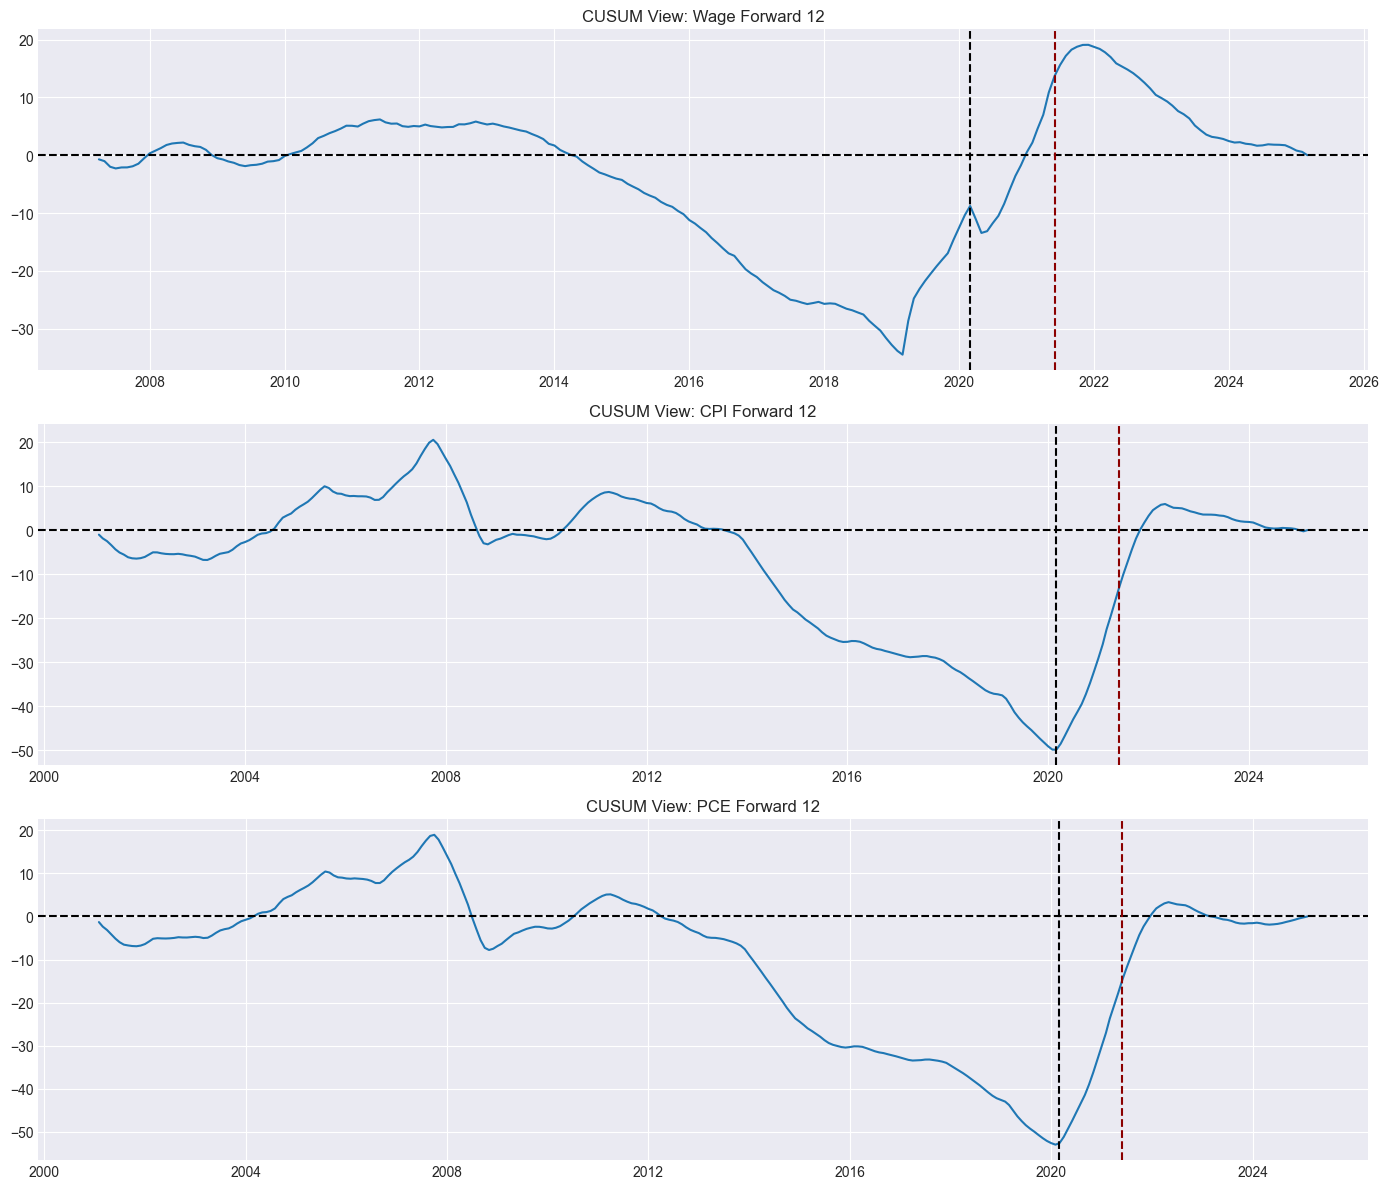

In [52]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, y_col, x_cols, title in [
    (axes[0], "wage_forward_12", ["log_jolts_ratio", "ahe_12m_pct_lag_1"], "CUSUM View: Wage Forward 12"),
    (axes[1], "cpi_forward_12", ["log_jolts_ratio", "cpi_12m_pct_lag_1"], "CUSUM View: CPI Forward 12"),
    (axes[2], "pce_forward_12", ["log_jolts_ratio", "pce_12m_pct_lag_1"], "CUSUM View: PCE Forward 12"),
]:
    use = df[["date", y_col] + x_cols].dropna().copy()
    x = sm.add_constant(use[x_cols])
    y = use[y_col]
    model = sm.OLS(y, x).fit()
    resid = model.resid.values
    path = np.cumsum(resid - resid.mean()) / resid.std(ddof=1)

    ax.plot(use["date"], path, linewidth=1.5)
    ax.axhline(0, color="black", linestyle="--")
    ax.axvline(candidate_break, color="black", linestyle="--")
    ax.axvline(post_start, color="darkred", linestyle="--")
    ax.set_title(title)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_cusum_paths.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## Pandemic Shock Versus Post-Pandemic Stabilization

The phase comparison regressions estimate the forecasting equations separately for the pandemic-shock period and the post-pandemic period. This separates the initial COVID disruption from the later reopening and inflation period. This matters because the pandemic shock and post-pandemic inflation surge are not the same economic regime.

The wage results show very strong labor-tightness coefficients during the pandemic shock, especially at shorter horizons. For 3-month wage growth, the shock-period log JOLTS coefficient is 11.5780, with a p-value effectively equal to zero and an R-squared of 0.7100. For 6-month wage growth, the coefficient is 5.2021, also highly significant, with an R-squared of 0.8799. For 12-month wage growth, the coefficient is 2.6416, also highly significant. These results suggest a very strong wage-tightness relationship during the shock period.

However, the shock-period sample has only 17 observations, so these results are fragile. The very high R-squared values likely reflect the extreme pandemic dynamics rather than a stable forecasting relationship. The post-pandemic wage coefficients are smaller but still positive and significant. They are 2.1588, 1.8759, and 1.6198 across the 3-, 6-, and 12-month horizons. The post-pandemic R-squared values are much lower, around 0.19 to 0.22, suggesting that the relationship normalized but remained weaker than during the shock.

The CPI shock-period results are weak. The shock-period log JOLTS coefficients are not statistically significant at any horizon. The post-pandemic CPI coefficients are also not statistically significant after including lagged CPI inflation. This supports the earlier conclusion that CPI inflation forecasting is not reliably explained by labor tightness once persistence is included.

The PCE shock-period results show that lagged PCE inflation matters during the shock, while the log JOLTS ratio is not consistently significant. In the post-pandemic period, lagged PCE inflation remains significant across horizons, while the log JOLTS ratio becomes negative and is marginal or significant at longer horizons. This again suggests that inflation persistence dominates the post-pandemic PCE forecasting equation.

The main conclusion is that the pandemic shock should not be pooled mechanically with the post-pandemic period. The shock period produces extreme relationships, especially for wages, but the post-pandemic period shows weaker and more mixed relationships. The final project should distinguish between temporary shock dynamics and post-pandemic stabilization dynamics.

In [53]:
phase_rows = []

for y_col, lag_col in [
    ("wage_forward_3", "ahe_12m_pct_lag_1"),
    ("wage_forward_6", "ahe_12m_pct_lag_1"),
    ("wage_forward_12", "ahe_12m_pct_lag_1"),
    ("cpi_forward_3", "cpi_12m_pct_lag_1"),
    ("cpi_forward_6", "cpi_12m_pct_lag_1"),
    ("cpi_forward_12", "cpi_12m_pct_lag_1"),
    ("pce_forward_3", "pce_12m_pct_lag_1"),
    ("pce_forward_6", "pce_12m_pct_lag_1"),
    ("pce_forward_12", "pce_12m_pct_lag_1"),
]:
    for label, part in [
        (SHOCK_LABEL, df[(df["date"] >= shock_start) & (df["date"] <= shock_end)].copy()),
        (POST_LABEL, df[df["date"] >= post_start].copy()),
    ]:
        use, model = fit_model(part, y_col, ["log_jolts_ratio", lag_col], cov_lag=6)
        if model is not None:
            out = coef_table(model, y_col, label)
            out["model_name"] = "phase_compare"
            phase_rows.append(out)

phase_data = pd.concat(phase_rows, axis=0).reset_index(drop=True)
phase_data.to_csv(REPORT_ROOT / "03_phase_compare_results.csv", index=False)

phase_data

,label,y_col,term,coef,std_error,t_stat,p_value,r2,adj_r2,obs,model_name
0,Pandemic Shock (2020-2021H1),wage_forward_3,const,9.0354,3.3983,2.6588,0.0078,0.7100,0.6686,17,phase_compare
1,Pandemic Shock (2020-2021H1),wage_forward_3,log_jolts_ratio,11.5780,2.3378,4.9526,0.0000,0.7100,0.6686,17,phase_compare
2,Pandemic Shock (2020-2021H1),wage_forward_3,ahe_12m_pct_lag_1,0.3539,0.4311,0.8209,0.4117,0.7100,0.6686,17,phase_compare
3,Post-Pandemic (2021-06+),wage_forward_3,const,5.6091,1.6615,3.3760,0.0007,0.1947,0.1631,54,phase_compare
4,Post-Pandemic (2021-06+),wage_forward_3,log_jolts_ratio,2.1588,0.8518,2.5344,0.0113,0.1947,0.1631,54,phase_compare
5,Post-Pandemic (2021-06+),wage_forward_3,ahe_12m_pct_lag_1,-0.4507,0.4131,-1.0910,0.2753,0.1947,0.1631,54,phase_compare
6,Pandemic Shock (2020-2021H1),wage_forward_6,const,4.7905,0.2875,16.6645,0.0000,0.8799,0.8627,17,phase_compare
7,Pandemic Shock (2020-2021H1),wage_forward_6,log_jolts_ratio,5.2021,0.4455,11.6767,0.0000,0.8799,0.8627,17,phase_compare
8,Pandemic Shock (2020-2021H1),wage_forward_6,ahe_12m_pct_lag_1,0.4198,0.0826,5.0802,0.0000,0.8799,0.8627,17,phase_compare
9,Post-Pandemic (2021-06+),wage_forward_6,const,5.2826,1.5642,3.3772,0.0007,0.2175,0.1856,52,phase_compare


## Multicollinearity Behavior

Multicollinearity occurs when predictors in a regression are highly correlated with each other. In this project, multicollinearity is expected because the log JOLTS ratio, unemployment rate, quits rate, and other labor-market indicators all measure related aspects of labor-market tightness. This is not a data error. It is an economic feature of the variables. The problem is that it makes individual regression coefficients harder to interpret.

If log labor tightness and unemployment are highly correlated, the model may struggle to assign the correct share of predictive value to each one. Coefficients can become unstable, standard errors can rise, and signs can become sensitive to small sample changes. This matters because the project wants to interpret the predictive value of labor tightness specifically.

### Heatmaps by Regime

The heatmap figure shows correlations among labor-market, wage, inflation, monetary-policy, credit-spread, and sentiment variables in each regime. Red indicates positive correlation, blue indicates negative correlation, and values closer to white indicate weaker correlation. The diagonal is always one because each variable is perfectly correlated with itself.

In the pre-2020 heatmap, the log JOLTS ratio and raw JOLTS ratio are highly positively correlated, as expected. Both are strongly negatively correlated with unemployment. This is natural because the ratio rises when openings rise or unemployment falls. The quits rate is also positively correlated with labor tightness. These relationships confirm that the core labor-market tightness variables are measuring related concepts.

In the pandemic-shock heatmap, correlations become more extreme and less stable. This is expected because the shock period has only a small number of observations and contains extraordinary movements. During short crisis windows, correlations can be dominated by a few months. The heatmap is useful for showing disruption, but it should not be treated as a stable long-run correlation matrix.

In the post-pandemic heatmap, labor tightness remains strongly related to quits and inflation variables, while unemployment is negatively related to tightness. The post-pandemic correlations among labor tightness, wage growth, CPI inflation, and PCE inflation are stronger than in the pre-pandemic period. This supports the idea that labor-market tightness became more connected to inflation during the post-pandemic period, although correlation alone does not prove predictive causality.

The main conclusion is that predictor relationships differ across regimes. This reinforces the need for regime-specific modeling and cautions against putting many related labor-market indicators into one regression without checking multicollinearity.

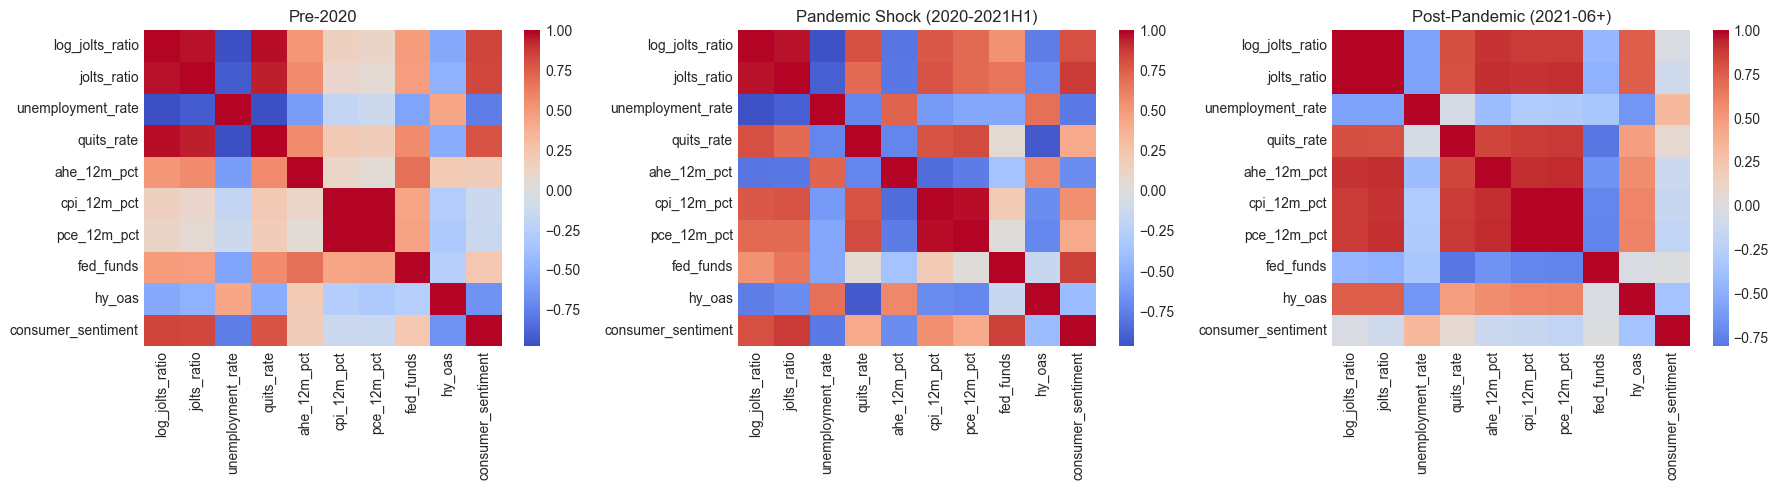

In [54]:
heat_cols = [
    "log_jolts_ratio",
    "jolts_ratio",
    "unemployment_rate",
    "quits_rate",
    "ahe_12m_pct",
    "cpi_12m_pct",
    "pce_12m_pct",
    "fed_funds",
    "hy_oas",
    "consumer_sentiment",
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, label in zip(axes, [PRE_LABEL, SHOCK_LABEL, POST_LABEL]):
    use = df.loc[df["regime"] == label, heat_cols].dropna().copy()
    sns.heatmap(use.corr(), cmap="coolwarm", center=0, annot=False, ax=ax)
    ax.set_title(label)

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_regime_heatmap.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

### Variance Inflation Factor

The wage VIF table shows severe multicollinearity among labor-market predictors. The VIF for log_jolts_ratio is 30.4671, the VIF for unemployment_rate is 14.5842, and the VIF for quits_rate is 10.9222. Values above 10 are usually considered high. This means these variables are strongly overlapping in information content.

The lagged wage-growth variable has a VIF of 4.1809, which is moderate but not severe. Fed funds, high-yield spreads, and consumer sentiment have lower VIF values. This suggests the main multicollinearity problem comes from including multiple labor-market tightness indicators together.

The inflation VIF table shows the same issue but somewhat less severely. The VIF for log_jolts_ratio is 14.0029, unemployment has a VIF of 8.4574, and quits have a VIF of 7.3864. These values still indicate meaningful overlap among labor-market predictors. Lagged CPI inflation, consumer sentiment, Fed funds, and high-yield spreads have lower VIF values.

The conclusion is that later forecasting models should avoid blindly including all labor-market indicators together in small samples. A better approach is to compare signal blocks, use regularization, or select one primary tightness measure at a time. For interpretability, the log JOLTS ratio should remain the central labor-market signal, while unemployment and quits can be used as robustness checks.

In [55]:
wage_vif = vif_table(df, ["log_jolts_ratio", "ahe_12m_pct_lag_1", "quits_rate", "unemployment_rate", "fed_funds", "hy_oas", "consumer_sentiment"])
wage_vif.to_csv(REPORT_ROOT / "03_wage_vif.csv", index=False)
wage_vif

,col,vif
0,log_jolts_ratio,30.4671
1,unemployment_rate,14.5842
2,quits_rate,10.9222
3,ahe_12m_pct_lag_1,4.1809
4,fed_funds,3.0484
5,hy_oas,2.2060
6,consumer_sentiment,1.7859


In [56]:
inflation_vif = vif_table(df, ["log_jolts_ratio", "cpi_12m_pct_lag_1", "quits_rate", "unemployment_rate", "fed_funds", "hy_oas", "consumer_sentiment"])
inflation_vif.to_csv(REPORT_ROOT / "03_inflation_vif.csv", index=False)
inflation_vif

,col,vif
0,log_jolts_ratio,14.0029
1,unemployment_rate,8.4574
2,quits_rate,7.3864
3,cpi_12m_pct_lag_1,2.5840
4,consumer_sentiment,2.5441
5,fed_funds,1.9018
6,hy_oas,1.7553


## Wage and Inflation Scatter by Regime and Horizon

The wage scatter plots compare the relationship between log labor tightness and future wage growth before 2020 and after June 2021. Each point is one monthly observation. The x-axis is the log JOLTS ratio. The y-axis is future wage growth at the specified horizon. The black regression line shows the fitted linear relationship, and the gray band shows uncertainty around the fitted line.

In the pre-2020 wage plots, the relationship is clearly positive at all horizons. The 12-month relationship is especially strong and visually tight compared with the shorter horizons. This matches the regression and correlation results showing that labor tightness is a meaningful wage-growth signal before COVID-19.

In the post-pandemic wage plots, the relationship remains positive, but the points are more dispersed and the fitted relationship is less precise. The range of log JOLTS values is also much narrower than in the pre-pandemic period because the post-pandemic sample is short and concentrated in a high-tightness regime. This limited variation makes it harder to estimate a stable slope.

The main wage conclusion is that the labor-tightness signal survives after COVID-19, but it is weaker and less stable. The post-pandemic wage relationship should be treated as suggestive because there are fewer observations and less variation than in the pre-pandemic sample.

The CPI scatter plots show a different pattern. Before 2020, the fitted lines are nearly flat, especially at the 6- and 12-month horizons. The points are widely scattered, and there is little visual evidence that labor tightness predicts future CPI inflation. This matches the weak pre-pandemic regression results.

After June 2021, the CPI scatter plots show a more positive relationship at the 3-month and 6-month horizons. However, the uncertainty bands are wide, and the 12-month relationship is weaker. The post-pandemic sample includes high-inflation observations during the inflation surge and later disinflation observations, so the fitted line may partly reflect the timing of one unusual episode rather than a stable structural relationship.

The main inflation conclusion is that labor tightness appears more related to CPI inflation after the pandemic than before it, but the evidence is much less stable than for wage growth. The relationship is strongest at short horizons and weaker at 12 months.

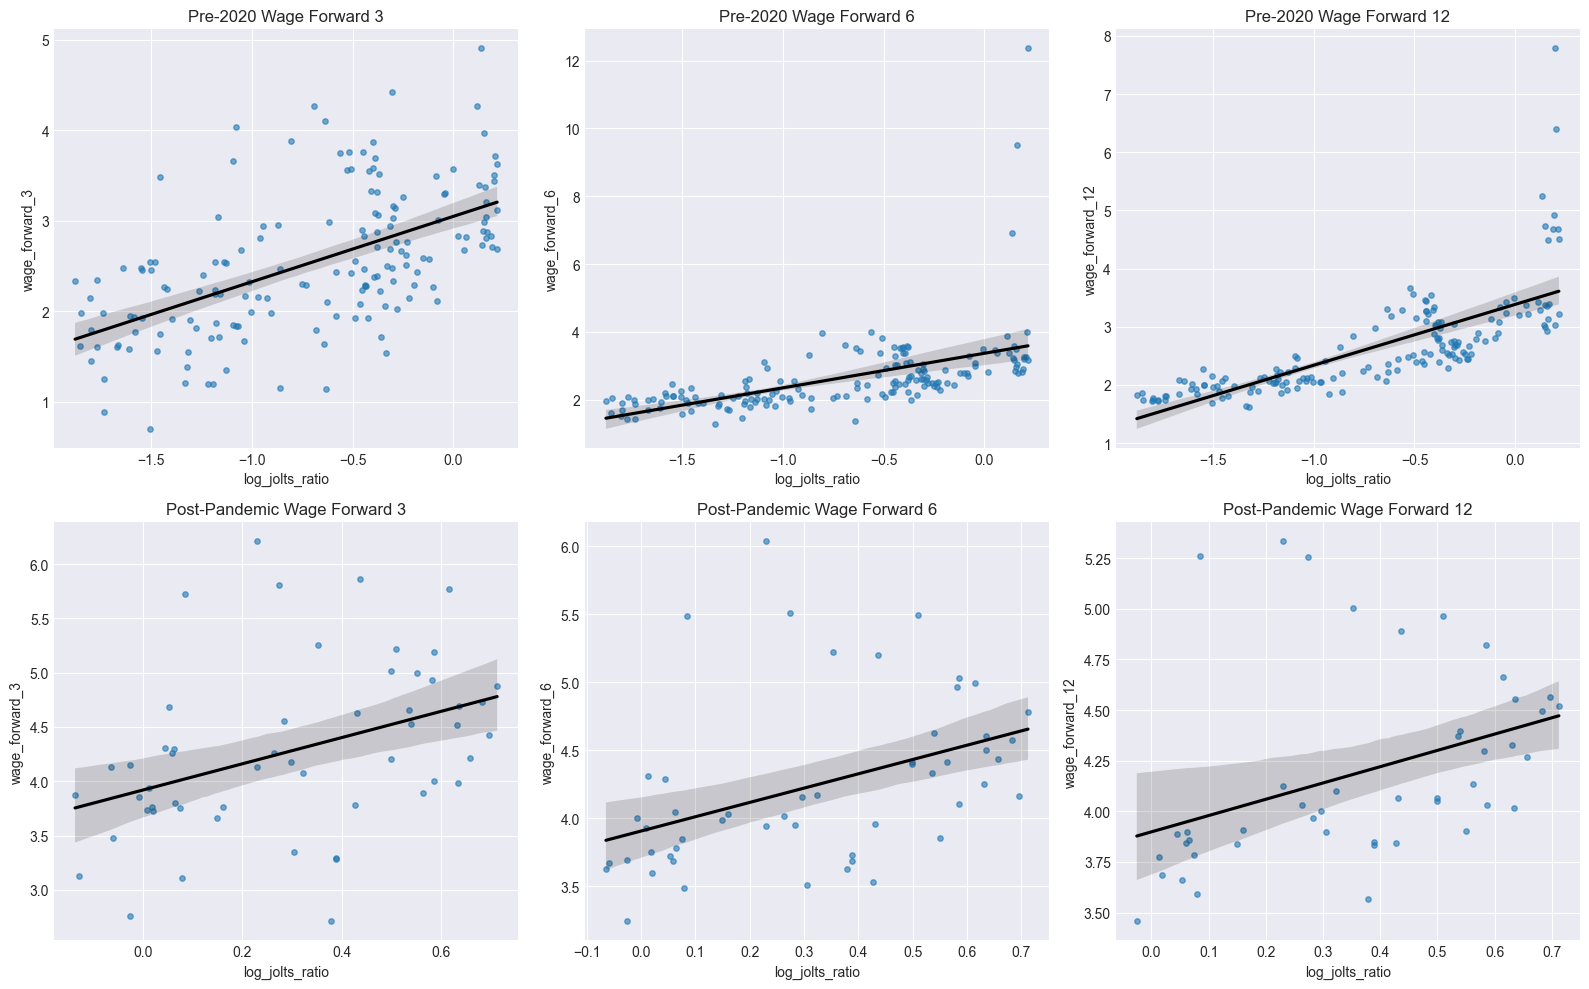

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=False, sharey=False)

for idx, horizon in enumerate([3, 6, 12]):
    sns.regplot(
        data=df[df["regime"] == PRE_LABEL],
        x="log_jolts_ratio",
        y=f"wage_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[0, idx],
    )
    axes[0, idx].set_title(f"Pre-2020 Wage Forward {horizon}")

    sns.regplot(
        data=df[df["regime"] == POST_LABEL],
        x="log_jolts_ratio",
        y=f"wage_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[1, idx],
    )
    axes[1, idx].set_title(f"Post-Pandemic Wage Forward {horizon}")

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_wage_scatter_by_horizon.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

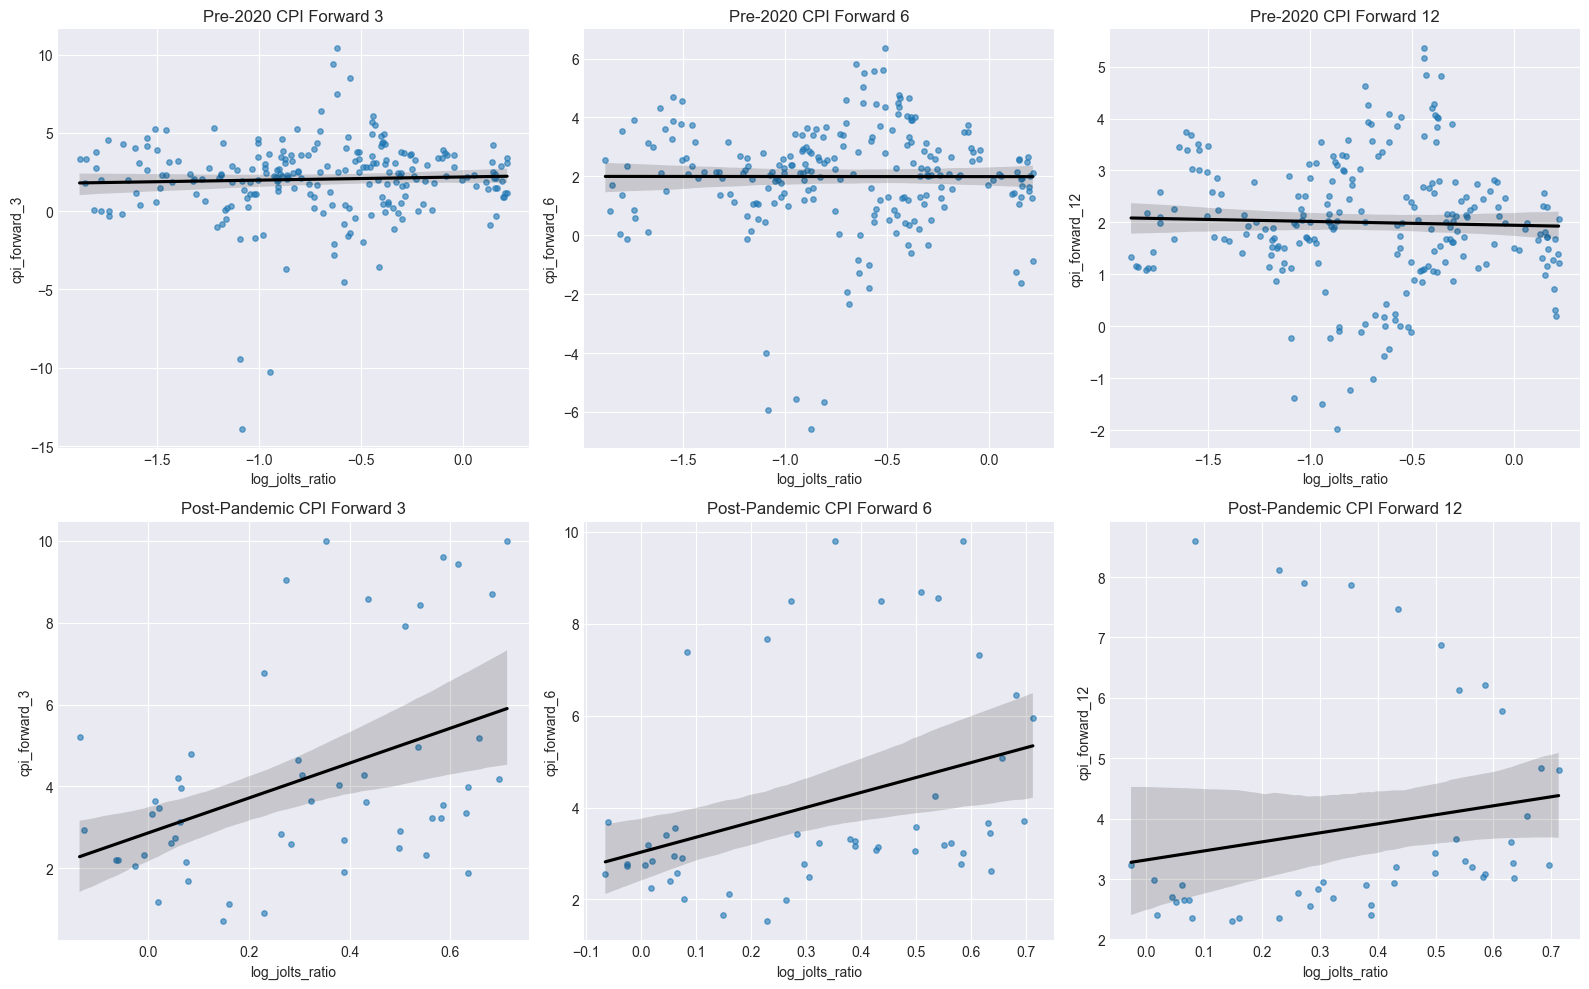

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=False, sharey=False)

for idx, horizon in enumerate([3, 6, 12]):
    sns.regplot(
        data=df[df["regime"] == PRE_LABEL],
        x="log_jolts_ratio",
        y=f"cpi_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[0, idx],
    )
    axes[0, idx].set_title(f"Pre-2020 CPI Forward {horizon}")

    sns.regplot(
        data=df[df["regime"] == POST_LABEL],
        x="log_jolts_ratio",
        y=f"cpi_forward_{horizon}",
        scatter_kws={"s": 15, "alpha": 0.6},
        line_kws={"color": "black"},
        ax=axes[1, idx],
    )
    axes[1, idx].set_title(f"Post-Pandemic CPI Forward {horizon}")

plt.tight_layout()
plt.savefig(FIG_ROOT / "03_cpi_scatter_by_horizon.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

## ECI Frequency Check

The ECI frequency check counts the months in which eci_total is nonmissing. The output shows observations across all months, with most months having 25 observations and November and December having 24. This suggests that the ECI series in the merged dataset may have been expanded or carried across months rather than appearing only in quarterly release months.

The notebook then creates an eci_flag table stating that eci_total should not be used in the monthly forward analysis because of its quarterly release structure. This is the right conservative choice. Even if the merged file contains monthly values, the underlying ECI data are not a standard monthly series in the same way as CPI or unemployment. Using it without handling release timing could create look-ahead bias or artificial monthly variation.

The next step is to either exclude ECI from monthly forecasting models or build a separate quarterly analysis where ECI is aligned properly to its release schedule. For this notebook, excluding ECI from the monthly forward model base is the safer decision.

In [59]:
eci_audit = df.loc[df["eci_total"].notna(), ["date", "eci_total"]].copy()
eci_audit["month"] = eci_audit["date"].dt.month
eci_months = eci_audit["month"].value_counts().sort_index()

eci_months

month
1     25
2     25
3     25
4     25
5     25
6     25
7     25
8     25
9     25
10    25
11    24
12    24
Name: count, dtype: int64

In [60]:
eci_flag = pd.DataFrame(
    [
        {
            "series": "eci_total",
            "use_in_monthly_forward_analysis": "no",
            "reason": "quarterly release structure",
        }
    ]
)

eci_flag.to_csv(REPORT_ROOT / "03_eci_audit.csv", index=False)
eci_flag

,series,use_in_monthly_forward_analysis,reason
0,eci_total,no,quarterly release structure


## Summary Audit

The summary audit table reports the final constructed dataset size after feature engineering. It shows 316 total observations and 178 total columns. The number of columns increases from the raw 135 because the notebook adds regime indicators, log variables, growth rates, forward targets, lagged variables, and other derived features.

The regime counts are 240 pre-2020 observations, 17 pandemic-shock observations, and 59 post-pandemic observations. This confirms the major sample imbalance. The pre-pandemic regime is long, while the shock and post-pandemic regimes are short. This matters for interpretation because statistical estimates from the post-pandemic period are more sensitive to individual observations.

The forward-target counts show that wage-forward targets have fewer usable observations than inflation-forward targets. There are 238 observations for 3-month wage growth, 235 for 6-month wage growth, and 229 for 12-month wage growth. CPI and PCE forward targets have more observations, with CPI ranging from 302 to 310 and PCE ranging from 302 to 311 depending on the horizon.

The conclusion is that the constructed dataset is ready for modeling, but the final model evaluation must be careful about sample sizes. In particular, post-pandemic 12-month models have relatively few observations because the horizon removes the last year of usable targets.

In [61]:
summary_audit = pd.DataFrame(
    [
        {"metric": "total_observations", "value": len(df)},
        {"metric": "total_columns", "value": len(df.columns)},
        {"metric": "pre_2020_observations", "value": int((df["regime"] == PRE_LABEL).sum())},
        {"metric": "shock_observations", "value": int((df["regime"] == SHOCK_LABEL).sum())},
        {"metric": "post_observations", "value": int((df["regime"] == POST_LABEL).sum())},
        {"metric": "wage_forward_3_obs", "value": int(df["wage_forward_3"].notna().sum())},
        {"metric": "wage_forward_6_obs", "value": int(df["wage_forward_6"].notna().sum())},
        {"metric": "wage_forward_12_obs", "value": int(df["wage_forward_12"].notna().sum())},
        {"metric": "cpi_forward_3_obs", "value": int(df["cpi_forward_3"].notna().sum())},
        {"metric": "cpi_forward_6_obs", "value": int(df["cpi_forward_6"].notna().sum())},
        {"metric": "cpi_forward_12_obs", "value": int(df["cpi_forward_12"].notna().sum())},
        {"metric": "pce_forward_3_obs", "value": int(df["pce_forward_3"].notna().sum())},
        {"metric": "pce_forward_6_obs", "value": int(df["pce_forward_6"].notna().sum())},
        {"metric": "pce_forward_12_obs", "value": int(df["pce_forward_12"].notna().sum())},
    ]
)

summary_audit.to_csv(REPORT_ROOT / "03_eda_summary.csv", index=False)
summary_audit

,metric,value
0,total_observations,316
1,total_columns,178
2,pre_2020_observations,240
3,shock_observations,17
4,post_observations,59
5,wage_forward_3_obs,238
6,wage_forward_6_obs,235
7,wage_forward_12_obs,229
8,cpi_forward_3_obs,310
9,cpi_forward_6_obs,308


## Findings for Modeling

The final key-table display gathers the main outputs into one place. This is useful as a notebook audit because it confirms that the regime summary, level-shift tests, tightness regressions, wage regressions, inflation regressions, interaction results, break tests, sup-F results, forward correlations, CUSUM tests, and VIF diagnostics have all been generated.

The combined results support several modeling decisions. First, regime labels are necessary because the post-pandemic data have different means and different relationships. Second, the log JOLTS ratio should remain a core labor-market tightness measure because it consistently predicts wage growth. Third, inflation models should include lagged inflation because inflation persistence often dominates the predictive relationship. Fourth, structural-break and CUSUM results show that static full-sample models are not reliable enough by themselves. Fifth, multicollinearity means that later models should avoid overloading regressions with many overlapping labor-market indicators unless regularization or careful feature grouping is used.

The key weakness is that this notebook is still mostly in-sample and diagnostic. It shows that relationships changed and that labor tightness has predictive associations, but it does not prove that any model forecasts well out of sample. The next notebook must evaluate actual forecasting performance using time-respecting train-test splits, rolling or expanding windows, and benchmark comparisons against persistence and autoregressive models.

Export Final EDA Modeling Base

The final export cell selects the columns needed for downstream modeling and saves them to 03_eda_model_base.csv. This is a clean modeling base that includes dates, regimes, tightness measures, wage and inflation growth rates, forward targets, lagged persistence controls, interest rates, credit spreads, and consumer sentiment.

The displayed first rows show that early observations contain missing values for variables that cannot yet be calculated. This is expected. Growth rates require past observations, forward targets require future observations, and JOLTS or wage variables begin later than the full CPI and unemployment sample. These missing values should not be filled mechanically. Instead, each model should drop missing rows only for the variables it actually uses.

The export is useful because it separates the EDA feature construction from later forecasting notebooks. Later notebooks should load this modeling base and then create forecasting splits, model matrices, and performance metrics from it.

In [62]:
key_tables = {
    "regime_summary": regime_summary,
    "level_data": level_data,
    "base_data": base_data,
    "wage_data": wage_data,
    "inflation_data": inflation_data,
    "interaction_data": interaction_data,
    "break_data": break_data,
    "sup_data": sup_data,
    "lead_data": lead_data,
    "cusum_data": cusum_data,
    "wage_vif": wage_vif,
    "inflation_vif": inflation_vif,
}

for name, part in key_tables.items():
    print(name)
    display(part.head(20))

regime_summary


jolts_ratio                             log_jolts_ratio                               quits_rate                             unemployment_rate                       \
                                   count   mean    std    min    max           count    mean    std     min    max      count   mean    std    min    max             count   mean    std    min   
regime                                                                                                                                                                                             
Pandemic Shock (2020-2021H1)          17 0.6892 0.3092 0.1995 1.2138              17 -0.4843 0.5165 -1.6118 0.1938         17 2.2059 0.3112 1.5000 2.7000                17 7.5176 3.1463 3.5000   
Post-Pandemic (2021-06+)              56 1.3771 0.3567 0.8730 2.0390              56  0.2868 0.2604 -0.1358 0.7124         57 2.3579 0.3530 1.9000 3.0000                57 4.0193 0.4775 3.4000   
Pre-2020                             229 0.5594 0.2841 0.1529 1.2419             229 -0.7140 0.5312 -1.8782 0.2166        229 1.9074 0.3000 1.2000 2.4000               240 5.8812 1.8095 3.5000   

                                     ahe_12m_pct                             cpi_12m_pct                              pce_12m_pct                               
                                 max       count   mean    std    min    max       count   mean    std     min    max       count   mean    std     min    max  
regime                                                                                                                                                          
Pandemic Shock (2020-2021H1) 14.8000          17 4.3808 1.6120 0.5974 7.7854          17 1.7319 1.2217  0.1980 4.8011          17 1.5849 0.9817  0.4614 3.9917  
Post-Pandemic (2021-06+)      5.9000          58 4.3543 0.5928 3.4566 5.7269          57 4.4440 2.0558  2.2988 8.5988          57 3.9168 1.5644  2.2356 6.9932  
Pre-2020                     10.0000         154 2.4821 0.5418 1.6261 3.6655         228 2.0802 1.2151 -1.9782 5.3517         228 1.7790 0.9713 -1.4769 4.0524

level_data


,col,left_date,right_date,mean_left,mean_right,diff,t_stat,p_value,n_left,n_right
0,jolts_ratio,2020-03-01,2021-06-01,0.5651,1.3771,0.8120,-15.8213,0.0000,231,56
1,log_jolts_ratio,2020-03-01,2021-06-01,-0.7061,0.2868,0.9930,-20.0502,0.0000,231,56
2,ahe_12m_pct,2020-03-01,2021-06-01,2.4889,4.3543,1.8654,-20.9361,0.0000,156,58
3,cpi_12m_pct,2020-03-01,2021-06-01,2.0833,4.4440,2.3607,-8.3193,0.0000,230,57
4,pce_12m_pct,2020-03-01,2021-06-01,1.7785,3.9168,2.1383,-9.8632,0.0000,230,57


base_data


...

,y_col,stat,p_value,crit_1,crit_5,crit_10,obs
0,wage_forward_12,2.3357,0.0000,1.6300,1.3600,1.2200,216
1,cpi_forward_12,2.9238,0.0000,1.6300,1.3600,1.2200,289
2,pce_forward_12,3.1032,0.0000,1.6300,1.3600,1.2200,289


wage_vif


,col,vif
0,log_jolts_ratio,30.4671
1,unemployment_rate,14.5842
2,quits_rate,10.9222
3,ahe_12m_pct_lag_1,4.1809
4,fed_funds,3.0484
5,hy_oas,2.2060
6,consumer_sentiment,1.7859


inflation_vif


,col,vif
0,log_jolts_ratio,14.0029
1,unemployment_rate,8.4574
2,quits_rate,7.3864
3,cpi_12m_pct_lag_1,2.5840
4,consumer_sentiment,2.5441
5,fed_funds,1.9018
6,hy_oas,1.7553


The final export cell selects the columns needed for downstream modeling and saves them to 03_eda_model_base.csv.

In [63]:
keep_cols = [
    "date",
    "regime",
    "post_regime",
    "shock_regime",
    "jolts_ratio",
    "log_jolts_ratio",
    "quits_rate",
    "unemployment_rate",
    "ahe_3m_pct",
    "ahe_6m_pct",
    "ahe_12m_pct",
    "cpi_3m_pct",
    "cpi_6m_pct",
    "cpi_12m_pct",
    "pce_3m_pct",
    "pce_6m_pct",
    "pce_12m_pct",
    "wage_forward_3",
    "wage_forward_6",
    "wage_forward_12",
    "cpi_forward_3",
    "cpi_forward_6",
    "cpi_forward_12",
    "pce_forward_3",
    "pce_forward_6",
    "pce_forward_12",
    "ahe_12m_pct_lag_1",
    "cpi_12m_pct_lag_1",
    "pce_12m_pct_lag_1",
    "fed_funds",
    "hy_oas",
    "consumer_sentiment",
]

eda_data = df[keep_cols].copy()
eda_data.to_csv(REPORT_ROOT / "03_eda_model_base.csv", index=False)

eda_data.head()

,date,regime,post_regime,shock_regime,jolts_ratio,log_jolts_ratio,quits_rate,unemployment_rate,ahe_3m_pct,ahe_6m_pct,ahe_12m_pct,cpi_3m_pct,cpi_6m_pct,cpi_12m_pct,pce_3m_pct,pce_6m_pct,pce_12m_pct,wage_forward_3,wage_forward_6,wage_forward_12,cpi_forward_3,cpi_forward_6,cpi_forward_12,pce_forward_3,pce_forward_6,pce_forward_12,ahe_12m_pct_lag_1,cpi_12m_pct_lag_1,pce_12m_pct_lag_1,fed_funds,hy_oas,consumer_sentiment
0,2000-01-01,Pre-2020,0,0,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7625,3.9767,3.6536,2.6393,2.6631,2.6656,NaN,NaN,NaN,5.4500,4.7843,112.0000
1,2000-02-01,Pre-2020,0,0,NaN,NaN,NaN,4.1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.8136,3.1515,3.4686,1.7124,2.0201,2.5055,NaN,NaN,NaN,5.7300,4.9024,111.3000
2,2000-03-01,Pre-2020,0,0,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.7972,3.0180,2.9388,1.3527,2.0223,2.0868,NaN,NaN,NaN,5.8500,5.3687,107.1000
3,2000-04-01,Pre-2020,0,0,NaN,NaN,NaN,3.8000,NaN,NaN,NaN,3.7625,NaN,NaN,2.6393,NaN,NaN,NaN,NaN,NaN,4.1910,3.4804,3.1676,2.6869,2.4602,2.3455,NaN,NaN,NaN,6.0200,5.8465,109.2000
4,2000-05-01,Pre-2020,0,0,NaN,NaN,NaN,4.0000,NaN,NaN,NaN,2.8136,NaN,NaN,1.7124,NaN,NaN,NaN,NaN,NaN,3.4894,3.4743,3.5011,2.3277,2.5737,2.5255,NaN,NaN,NaN,6.2700,5.8978,110.7000


## **Conclusion and Next Steps**

The notebook shows that the post-pandemic period is not just a noisy extension of the pre-2020 economy. It is a different forecasting environment. Labor-market tightness, wage growth, CPI inflation, and PCE inflation all shifted upward after COVID-19, and the formal stability tests show that the relationships between these variables changed over time. The central conclusion is that **the job-openings-to-unemployment ratio remains useful for forecasting wage growth, but it is not a stable or reliable standalone predictor of inflation after COVID-19**.

For wages, the evidence is strongest. The JOLTS ratio has a consistent positive relationship with future wage growth across horizons, including after controlling for lagged wage growth. However, the strength of this relationship changes after the pandemic. The post-pandemic wage relationship is weaker, noisier, and less stable than the pre-pandemic relationship, especially at the 12-month horizon. This means labor tightness still contains wage information, but a model trained only on pre-pandemic data should not be trusted without regime controls or rolling re-estimation.

For inflation, the evidence is more conditional. Before 2020, labor tightness does not meaningfully predict future CPI or PCE inflation. After the pandemic, the relationship becomes more visible at short horizons, but it weakens once lagged inflation is included. This means the post-pandemic inflation surge cannot be explained by labor tightness alone. Inflation persistence, supply shocks, monetary conditions, and broader macro state variables likely matter more than the JOLTS ratio by itself.

The structural-break evidence is the main contribution of the notebook. Chow tests, rolling coefficients, and CUSUM tests all point to instability in the forecasting equations. This supports the project’s thesis: **labor-market signals did not become useless after COVID-19, but their predictive value became regime-dependent, horizon-dependent, and target-dependent**. The wage signal is stronger than the inflation signal. The 3- and 6-month inflation relationships are more informative than the 12-month relationship. The post-pandemic period should therefore be modeled as a distinct regime rather than pooled mechanically with the pre-pandemic period.

# Clear Next Steps

The next notebook should move from in-sample diagnostic evidence to true out-of-sample forecasting. Use an expanding-window or rolling-window design where each model is trained only on information available up to the forecast date. Compare persistence, autoregressive models, OLS, Ridge, ElasticNet, Random Forest, and Gradient Boosting across wage, CPI, and PCE targets at 3-, 6-, and 12-month horizons.

The forecast evaluation should report RMSE, MAE, and relative improvement versus a simple benchmark. The benchmark should be a persistence or autoregressive model because inflation and wage growth are persistent. A model should only be treated as useful if it beats this benchmark out of sample, not just because it has a significant in-sample coefficient.

The post-pandemic evaluation should be separated from the full-sample evaluation. Report results for the full test period and then separately for the post-June-2021 period. However, state clearly that the post-pandemic test sample is short, especially for 12-month horizons, so those results are suggestive rather than definitive.

The model comparison should answer three specific questions. First, does the JOLTS ratio improve wage forecasts beyond lagged wage growth? Second, does the JOLTS ratio improve inflation forecasts beyond lagged inflation? Third, do machine-learning models adapt better to regime instability than simpler regularized linear models? These questions should become the organizing structure of the final results notebook.

The visuals should be polished into a final figure set. Keep only figures that support the argument: a regime timeline, a forward-correlation plot by target and horizon, rolling coefficient plots, CUSUM stability plots, and an out-of-sample forecast-performance chart. Every figure should have a direct title that states the finding, not just the variable names.

The final README should state the finished finding plainly: **post-pandemic labor tightness remains informative for wage growth, but inflation forecasting is less stable and more dependent on persistence and regime conditions. Machine learning should be evaluated as a robustness tool, not assumed to solve structural instability automatically.**
